In [1]:
# Cell 1: Setup and frozen protocol
import gc
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    import psutil
except ImportError:
    psutil = None


def find_project_root():
    """Locate the repository root."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "phase1" / "src").is_dir():
            return candidate
    raise FileNotFoundError("Cannot locate the project root.")


PROJECT_ROOT = find_project_root()
PHASE_DIR = PROJECT_ROOT / "phase1"
SOURCE_DIR = PHASE_DIR / "src"
DATA_DIR = PHASE_DIR / "segmentated_data" / "dhdata"
RESULTS_DIR = PHASE_DIR / "results" / "rqa"
INDEX_PATH = DATA_DIR / "segments_index.csv"

if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

from dataloader.loader import load_segmented_session
from rqa.rqa import run_rqa

M = 8
TAU_SECONDS = {"Processed": 0.16, "Raw": 0.20}
TARGET_RR = 0.02
L_MIN = 2
V_MIN = 2
RR_TOLERANCE = 5e-5
WINDOW_SIZES = (60, 120, 180)
REPRESENTATIONS = ("Processed", "Raw")
STATES = ("Awake", "Drowsy")
STATE_LABELS = {0: "Awake", 1: "Drowsy"}
METRICS = ("DET", "Lmean", "ENTR", "Lmax", "LAM", "TT", "Vmax")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
WINDOW_OUTPUT = RESULTS_DIR / "rqa_window_level.csv"
QC_OUTPUT = RESULTS_DIR / "rqa_qc_summary.csv"
SESSION_OUTPUT = RESULTS_DIR / "rqa_session_state_summary.csv"
DELTA_OUTPUT = RESULTS_DIR / "rqa_session_paired_deltas.csv"
RQ2_OUTPUT = RESULTS_DIR / "rqa_rq2_summary.csv"

protocol = pd.DataFrame(
    {
        "parameter": [
            "Embedding dimension",
            "Processed tau",
            "Raw tau",
            "Theiler rule",
            "Distance",
            "Target RR",
            "Minimum diagonal line",
            "Minimum vertical line",
            "Processed eligibility",
            "Raw eligibility",
        ],
        "value": [
            M,
            f"{TAU_SECONDS['Processed']:.2f} s",
            f"{TAU_SECONDS['Raw']:.2f} s",
            "(m - 1) * tau_samples",
            "Euclidean",
            TARGET_RR,
            L_MIN,
            V_MIN,
            "SQI + Processed stationarity",
            "SQI only; stationarity disabled",
        ],
    }
)

session_files = sorted(DATA_DIR.glob("*.npz"))
print(f"Sessions found: {len(session_files)}")
display(protocol)


Sessions found: 20


,parameter,value
0,Embedding dimension,8
1,Processed tau,0.16 s
2,Raw tau,0.20 s
3,Theiler rule,(m - 1) * tau_samples
4,Distance,Euclidean
5,Target RR,0.02
6,Minimum diagonal line,2
7,Minimum vertical line,2
8,Processed eligibility,SQI + Processed stationarity
9,Raw eligibility,SQI only; stationarity disabled


In [2]:
# Cell 2: Coverage and paired availability
segment_index = pd.read_csv(INDEX_PATH)

for column in (
    "stationarity_pass_raw",
    "stationarity_pass_processed",
):
    if segment_index[column].dtype != bool:
        segment_index[column] = (
            segment_index[column]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({"true": True, "false": False})
        )
    if segment_index[column].isna().any():
        raise ValueError(f"Invalid boolean values in {column}.")

segment_index["session"] = segment_index["npz_file"].map(
    lambda value: Path(value).stem
)
segment_index["state"] = segment_index["label"].map(STATE_LABELS)

raw_index = segment_index.assign(representation="Raw")
processed_index = segment_index.loc[
    segment_index["stationarity_pass_processed"]
].assign(representation="Processed")
eligible_index = pd.concat(
    [processed_index, raw_index],
    ignore_index=True,
)

coverage_columns = [
    "session",
    "representation",
    "state",
    "window_size_s",
]
coverage = (
    eligible_index.groupby(coverage_columns, observed=True)
    .size()
    .rename("n_windows")
)
expected_index = pd.MultiIndex.from_product(
    [
        sorted(segment_index["session"].unique()),
        REPRESENTATIONS,
        STATES,
        WINDOW_SIZES,
    ],
    names=coverage_columns,
)
coverage = (
    coverage.reindex(expected_index, fill_value=0)
    .reset_index()
    .sort_values(coverage_columns)
    .reset_index(drop=True)
)

paired = coverage.pivot_table(
    index=["session", "representation", "window_size_s"],
    columns="state",
    values="n_windows",
    fill_value=0,
)
paired["paired"] = (paired["Awake"] > 0) & (paired["Drowsy"] > 0)
paired_sessions = (
    paired.reset_index()
    .groupby(["representation", "window_size_s"], observed=True)["paired"]
    .sum()
    .rename("n_paired_sessions")
    .reset_index()
)

display(coverage)
display(paired_sessions)

missing_coverage = coverage.loc[coverage["n_windows"] == 0]
if not missing_coverage.empty:
    display(missing_coverage)
    raise RuntimeError("Coverage check failed; inspect missing groups.")

print("Coverage check: PASS")


,session,representation,state,window_size_s,n_windows
0,sample_1,Processed,Awake,60,24
1,sample_1,Processed,Awake,120,11
2,sample_1,Processed,Awake,180,6
3,sample_1,Processed,Drowsy,60,7
4,sample_1,Processed,Drowsy,120,1
...,...,...,...,...,...
235,sample_9,Raw,Awake,120,22
236,sample_9,Raw,Awake,180,13
237,sample_9,Raw,Drowsy,60,21
238,sample_9,Raw,Drowsy,120,10


,representation,window_size_s,n_paired_sessions
0,Processed,60,20
1,Processed,120,20
2,Processed,180,20
3,Raw,60,20
4,Raw,120,20
5,Raw,180,20


Coverage check: PASS


In [3]:
# Cell 3: Full window-level RQA
WINDOW_COLUMNS = [
    "session",
    "representation",
    "state",
    "window_size",
    "window_id",
    "fs",
    "tau_samples",
    "theiler_samples",
    "epsilon",
    "target_rr",
    "achieved_rr",
    *METRICS,
    "n_diagonal_lines",
    "n_vertical_lines",
]
KEY_COLUMNS = [
    "session",
    "representation",
    "state",
    "window_size",
    "window_id",
]
CHECKPOINT_EVERY = 10


def estimate_peak_gib(n_samples, tau_samples):
    """Estimate conservative peak memory for one RQA window."""
    n_vectors = n_samples - (M - 1) * tau_samples
    return 28 * n_vectors**2 / 1024**3


def validate_checkpoint(frame, expected_keys):
    """Validate a resumable window-level checkpoint."""
    missing = set(WINDOW_COLUMNS).difference(frame.columns)
    if missing:
        raise ValueError(f"Checkpoint columns missing: {sorted(missing)}")
    if frame.duplicated(KEY_COLUMNS).any():
        raise ValueError("Checkpoint contains duplicate window keys.")

    keys = set(frame[KEY_COLUMNS].itertuples(index=False, name=None))
    if not keys.issubset(expected_keys):
        raise ValueError("Checkpoint contains unexpected window keys.")
    if not set(frame["representation"]).issubset(REPRESENTATIONS):
        raise ValueError("Checkpoint contains an invalid representation.")
    if not np.allclose(frame["target_rr"], TARGET_RR):
        raise ValueError("Checkpoint uses a different target RR.")
    expected_tau = np.rint(
        frame["fs"] * frame["representation"].map(TAU_SECONDS)
    ).astype(int)
    if not np.array_equal(frame["tau_samples"], expected_tau):
        raise ValueError("Checkpoint uses a different embedding delay.")
    expected_theiler = (M - 1) * expected_tau
    if not np.array_equal(frame["theiler_samples"], expected_theiler):
        raise ValueError("Checkpoint uses a different Theiler window.")


def append_records(records, output_path):
    """Append scalar RQA records to the master output."""
    if not records:
        return
    frame = pd.DataFrame.from_records(records, columns=WINDOW_COLUMNS)
    frame.to_csv(
        output_path,
        mode="a",
        header=not output_path.exists(),
        index=False,
    )
    records.clear()


expected_rows = eligible_index.loc[
    :,
    [
        "session",
        "representation",
        "state",
        "window_size_s",
        "window_id",
    ],
].rename(columns={"window_size_s": "window_size"})
if expected_rows.duplicated(KEY_COLUMNS).any():
    raise ValueError("Eligible metadata contains duplicate window keys.")
expected_keys = set(
    expected_rows[KEY_COLUMNS].itertuples(index=False, name=None)
)

if WINDOW_OUTPUT.exists():
    checkpoint = pd.read_csv(WINDOW_OUTPUT)
    validate_checkpoint(checkpoint, expected_keys)
    completed_keys = set(
        checkpoint[KEY_COLUMNS].itertuples(index=False, name=None)
    )
else:
    checkpoint = pd.DataFrame(columns=WINDOW_COLUMNS)
    completed_keys = set()

tasks = (
    eligible_index[
        ["session", "representation", "window_size_s"]
    ]
    .drop_duplicates()
    .sort_values(["session", "representation", "window_size_s"])
    .itertuples(index=False, name=None)
)
tasks = list(tasks)
records = []

print(f"Expected windows: {len(expected_keys)}")
print(f"Windows already complete: {len(completed_keys)}")

for task_number, (session, representation, window_size) in enumerate(
    tasks,
    start=1,
):
    stationarity_only = representation == "Processed"
    batches, _ = load_segmented_session(
        session=session,
        data_dir=DATA_DIR,
        window_sizes=(int(window_size),),
        representation=representation.lower(),
        stationarity_only=stationarity_only,
    )
    batch = batches[int(window_size)]
    tau_samples = int(round(TAU_SECONDS[representation] * batch["fs"]))
    peak_gib = estimate_peak_gib(batch["n_samples"], tau_samples)

    if psutil is not None:
        available_gib = psutil.virtual_memory().available / 1024**3
        if available_gib < 1.25 * peak_gib:
            raise MemoryError(
                "Insufficient free RAM for the next RQA window: "
                f"{available_gib:.2f} GiB available, "
                f"{peak_gib:.2f} GiB estimated peak."
            )

    for array_index, window_id in enumerate(batch["window_id"]):
        state = STATE_LABELS[int(batch["label"][array_index])]
        key = (
            session,
            representation,
            state,
            int(window_size),
            int(window_id),
        )
        if key in completed_keys:
            continue

        signal = batch["signal"][array_index]
        result = run_rqa(
            signal,
            m=M,
            tau=tau_samples,
            l_min=L_MIN,
            v_min=V_MIN,
            target_rr=TARGET_RR,
        )
        records.append(
            {
                "session": session,
                "representation": representation,
                "state": state,
                "window_size": int(window_size),
                "window_id": int(window_id),
                "fs": float(batch["fs"]),
                "tau_samples": tau_samples,
                "theiler_samples": result.theiler,
                "epsilon": result.epsilon,
                "target_rr": result.target_rr,
                "achieved_rr": result.achieved_rr,
                "DET": result.det,
                "Lmean": result.l_mean,
                "ENTR": result.entr,
                "Lmax": result.l_max,
                "LAM": result.lam,
                "TT": result.tt,
                "Vmax": result.v_max,
                "n_diagonal_lines": result.n_diagonal_lines,
                "n_vertical_lines": result.n_vertical_lines,
            }
        )
        completed_keys.add(key)
        del signal, result

        if len(records) >= CHECKPOINT_EVERY:
            append_records(records, WINDOW_OUTPUT)

    append_records(records, WINDOW_OUTPUT)
    del batches, batch
    gc.collect()
    print(
        f"Task {task_number}/{len(tasks)} complete: "
        f"{session}, {representation}, {window_size} s; "
        f"estimated peak {peak_gib:.2f} GiB"
    )

window_results = pd.read_csv(WINDOW_OUTPUT)
validate_checkpoint(window_results, expected_keys)
actual_keys = set(
    window_results[KEY_COLUMNS].itertuples(index=False, name=None)
)
if actual_keys != expected_keys:
    raise RuntimeError("Window-level RQA output is incomplete.")

window_results = window_results.sort_values(KEY_COLUMNS).reset_index(drop=True)
window_results.to_csv(WINDOW_OUTPUT, index=False)
display(window_results.head())
print(f"Window-level rows saved: {len(window_results)}")


Expected windows: 3181
Windows already complete: 3181
Task 1/120 complete: sample_1, Processed, 60 s; estimated peak 0.23 GiB
Task 2/120 complete: sample_1, Processed, 120 s; estimated peak 0.92 GiB


Task 3/120 complete: sample_1, Processed, 180 s; estimated peak 2.09 GiB
Task 4/120 complete: sample_1, Raw, 60 s; estimated peak 0.22 GiB


Task 5/120 complete: sample_1, Raw, 120 s; estimated peak 0.92 GiB


Task 6/120 complete: sample_1, Raw, 180 s; estimated peak 2.08 GiB
Task 7/120 complete: sample_10, Processed, 60 s; estimated peak 0.06 GiB
Task 8/120 complete: sample_10, Processed, 120 s; estimated peak 0.23 GiB


Task 9/120 complete: sample_10, Processed, 180 s; estimated peak 0.52 GiB
Task 10/120 complete: sample_10, Raw, 60 s; estimated peak 0.06 GiB
Task 11/120 complete: sample_10, Raw, 120 s; estimated peak 0.23 GiB


...

Task 113/120 complete: sample_8, Raw, 120 s; estimated peak 0.23 GiB
Task 114/120 complete: sample_8, Raw, 180 s; estimated peak 0.52 GiB
Task 115/120 complete: sample_9, Processed, 60 s; estimated peak 0.06 GiB


Task 116/120 complete: sample_9, Processed, 120 s; estimated peak 0.23 GiB
Task 117/120 complete: sample_9, Processed, 180 s; estimated peak 0.52 GiB
Task 118/120 complete: sample_9, Raw, 60 s; estimated peak 0.06 GiB


Task 119/120 complete: sample_9, Raw, 120 s; estimated peak 0.23 GiB
Task 120/120 complete: sample_9, Raw, 180 s; estimated peak 0.52 GiB


,session,representation,state,window_size,window_id,fs,tau_samples,theiler_samples,epsilon,target_rr,achieved_rr,DET,Lmean,ENTR,Lmax,LAM,TT,Vmax,n_diagonal_lines,n_vertical_lines
0,sample_1,Processed,Awake,60,1,50.0,8,56,117.450855,0.02,0.02,0.904122,4.727985,1.935400,132,0.644140,2.389823,5,15944,44946
1,sample_1,Processed,Awake,60,2,50.0,8,56,109.782483,0.02,0.02,0.913465,4.812765,1.942604,164,0.705069,2.467688,5,15825,47645
2,sample_1,Processed,Awake,60,3,50.0,8,56,114.637603,0.02,0.02,0.911378,4.610083,1.914764,149,0.713956,2.482122,5,16483,47965
3,sample_1,Processed,Awake,60,4,50.0,8,56,101.614095,0.02,0.02,0.929393,5.266055,2.047586,161,0.560113,2.272143,5,14715,41107
4,sample_1,Processed,Awake,60,5,50.0,8,56,108.734577,0.02,0.02,0.915672,4.775206,1.917850,168,0.638258,2.351673,5,15988,45258


Window-level rows saved: 3181


In [4]:
# Cell 4: Full-dataset quality control
window_results = pd.read_csv(WINDOW_OUTPUT)
numeric_columns = [
    "fs",
    "tau_samples",
    "theiler_samples",
    "epsilon",
    "target_rr",
    "achieved_rr",
    *METRICS,
    "n_diagonal_lines",
    "n_vertical_lines",
]
numeric_values = window_results[numeric_columns].to_numpy(dtype=float)

quality = window_results[
    ["representation", "window_size"]
].copy()
quality["invalid_output"] = ~np.isfinite(numeric_values).all(axis=1)
quality["rr_error"] = (
    window_results["achieved_rr"] - TARGET_RR
).abs()
quality["zero_diagonal_support"] = (
    window_results["n_diagonal_lines"] == 0
)
quality["zero_vertical_support"] = (
    window_results["n_vertical_lines"] == 0
)
quality["invalid_det_lam"] = (
    ~window_results["DET"].between(0.0, 1.0)
    | ~window_results["LAM"].between(0.0, 1.0)
)
quality["invalid_metric"] = (
    (window_results[["Lmean", "ENTR", "Lmax", "TT", "Vmax"]] < 0)
    .any(axis=1)
    | (window_results["epsilon"] <= 0)
    | ~window_results["achieved_rr"].between(0.0, 1.0)
    | (window_results["n_diagonal_lines"] < 0)
    | (window_results["n_vertical_lines"] < 0)
)
quality["lmax_below_lmean"] = (
    window_results["Lmax"] < window_results["Lmean"]
)
quality["vmax_below_tt"] = (
    window_results["Vmax"] < window_results["TT"]
)

qc_summary = (
    quality.groupby(
        ["representation", "window_size"],
        observed=True,
    )
    .agg(
        n_windows=("invalid_output", "size"),
        invalid_outputs=("invalid_output", "sum"),
        max_rr_error=("rr_error", "max"),
        zero_diagonal_support=("zero_diagonal_support", "sum"),
        zero_vertical_support=("zero_vertical_support", "sum"),
        invalid_det_lam=("invalid_det_lam", "sum"),
        invalid_metrics=("invalid_metric", "sum"),
        lmax_below_lmean=("lmax_below_lmean", "sum"),
        vmax_below_tt=("vmax_below_tt", "sum"),
    )
    .reset_index()
)
qc_summary.to_csv(QC_OUTPUT, index=False)
display(qc_summary)

qc_pass = (
    qc_summary["invalid_outputs"].sum() == 0
    and qc_summary["max_rr_error"].max() <= RR_TOLERANCE
    and qc_summary["zero_diagonal_support"].sum() == 0
    and qc_summary["zero_vertical_support"].sum() == 0
    and qc_summary["invalid_det_lam"].sum() == 0
    and qc_summary["invalid_metrics"].sum() == 0
    and qc_summary["lmax_below_lmean"].sum() == 0
    and qc_summary["vmax_below_tt"].sum() == 0
)
print(f"Full-dataset QC: {'PASS' if qc_pass else 'FAIL'}")

if not qc_pass:
    raise RuntimeError("Full-dataset QC failed; stop before aggregation.")


,representation,window_size,n_windows,invalid_outputs,max_rr_error,zero_diagonal_support,zero_vertical_support,invalid_det_lam,invalid_metrics,lmax_below_lmean,vmax_below_tt
0,Processed,60,901,0,9.034960e-07,0,0,0,0,0,0
1,Processed,120,405,0,2.171325e-07,0,0,0,0,0,0
2,Processed,180,238,0,9.525833e-08,0,0,0,0,0,0
3,Raw,60,951,0,3.229800e-06,0,0,0,0,0,0
4,Raw,120,432,0,7.690542e-07,0,0,0,0,0,0
5,Raw,180,254,0,3.363834e-07,0,0,0,0,0,0


Full-dataset QC: PASS


In [5]:
# Cell 5: Session-level aggregation
aggregation = {}
for metric in METRICS:
    aggregation[f"{metric}_mean"] = (metric, "mean")
    aggregation[f"{metric}_std"] = (metric, "std")
    aggregation[f"{metric}_median"] = (metric, "median")

session_summary = (
    window_results.groupby(
        ["session", "representation", "state", "window_size"],
        observed=True,
    )
    .agg(
        n_windows=("window_id", "size"),
        **aggregation,
    )
    .reset_index()
    .sort_values(
        ["session", "representation", "state", "window_size"]
    )
    .reset_index(drop=True)
)
session_summary.to_csv(SESSION_OUTPUT, index=False)
display(session_summary.head(12))
print(f"Session-state rows saved: {len(session_summary)}")


,session,representation,state,window_size,n_windows,DET_mean,DET_std,DET_median,Lmean_mean,Lmean_std,...,Lmax_median,LAM_mean,LAM_std,LAM_median,TT_mean,TT_std,TT_median,Vmax_mean,Vmax_std,Vmax_median
0,sample_1,Processed,Awake,60,24,0.918084,0.012299,0.919174,4.966876,0.329073,...,174.0,0.735153,0.091974,0.725728,2.509224,0.220576,2.459658,6.041667,1.458980,5.5
1,sample_1,Processed,Awake,120,11,0.918575,0.010609,0.919850,4.985234,0.291687,...,244.0,0.759895,0.073615,0.783228,2.520243,0.117312,2.569770,7.000000,1.897367,7.0
2,sample_1,Processed,Awake,180,6,0.917676,0.010463,0.914929,4.973382,0.311559,...,243.0,0.754826,0.058492,0.749737,2.500680,0.068003,2.507126,6.666667,1.632993,6.5
3,sample_1,Processed,Drowsy,60,7,0.931293,0.014919,0.939096,5.256252,0.353057,...,204.0,0.802732,0.043888,0.791435,2.527758,0.152916,2.448311,7.428571,2.636737,7.0
4,sample_1,Processed,Drowsy,120,1,0.935083,NaN,0.935083,5.367463,NaN,...,264.0,0.817028,NaN,0.817028,2.503560,NaN,2.503560,11.000000,NaN,11.0
5,sample_1,Processed,Drowsy,180,1,0.936743,NaN,0.936743,5.356364,NaN,...,264.0,0.807938,NaN,0.807938,2.478091,NaN,2.478091,11.000000,NaN,11.0
6,sample_1,Raw,Awake,60,24,0.952835,0.016289,0.949780,5.431057,0.935633,...,190.5,0.975446,0.011095,0.975214,5.105385,0.971253,4.799231,18.875000,15.962762,12.5
7,sample_1,Raw,Awake,120,11,0.956167,0.015222,0.948174,5.488960,0.749784,...,240.0,0.979468,0.008898,0.976994,5.386829,0.888116,5.185907,35.272727,26.608611,22.0
8,sample_1,Raw,Awake,180,6,0.957421,0.016227,0.956498,5.514059,0.879399,...,293.5,0.981262,0.008589,0.981561,5.586561,0.878337,5.578976,32.333333,23.491843,21.5
9,sample_1,Raw,Drowsy,60,10,0.971449,0.009148,0.969861,7.351509,1.999075,...,241.5,0.986043,0.004377,0.985218,6.335171,2.016957,5.521265,52.300000,61.573894,23.0


Session-state rows saved: 240


In [6]:
# Cell 6: Paired Awake-Drowsy contrasts
group_columns = ["session", "representation", "window_size"]
mean_columns = [f"{metric}_mean" for metric in METRICS]

awake = session_summary.loc[
    session_summary["state"] == "Awake",
    [*group_columns, "n_windows", *mean_columns],
].rename(
    columns={
        "n_windows": "n_awake_windows",
        **{
            column: f"{column}_awake"
            for column in mean_columns
        },
    }
)
drowsy = session_summary.loc[
    session_summary["state"] == "Drowsy",
    [*group_columns, "n_windows", *mean_columns],
].rename(
    columns={
        "n_windows": "n_drowsy_windows",
        **{
            column: f"{column}_drowsy"
            for column in mean_columns
        },
    }
)

paired_deltas = awake.merge(
    drowsy,
    on=group_columns,
    how="inner",
    validate="one_to_one",
)
for metric in METRICS:
    paired_deltas[f"delta_{metric}"] = (
        paired_deltas[f"{metric}_mean_drowsy"]
        - paired_deltas[f"{metric}_mean_awake"]
    )

delta_columns = [f"delta_{metric}" for metric in METRICS]
paired_deltas = paired_deltas[
    [
        *group_columns,
        "n_awake_windows",
        "n_drowsy_windows",
        *delta_columns,
    ]
].sort_values(group_columns).reset_index(drop=True)
paired_deltas.to_csv(DELTA_OUTPUT, index=False)
display(paired_deltas.head(12))
print(f"Paired session rows saved: {len(paired_deltas)}")


,session,representation,window_size,n_awake_windows,n_drowsy_windows,delta_DET,delta_Lmean,delta_ENTR,delta_Lmax,delta_LAM,delta_TT,delta_Vmax
0,sample_1,Processed,60,24,7,0.013209,0.289376,0.043494,25.607143,0.067579,0.018534,1.386905
1,sample_1,Processed,120,11,1,0.016508,0.382229,0.046358,29.454545,0.057133,-0.016683,4.000000
2,sample_1,Processed,180,6,1,0.019067,0.382981,0.040448,29.333333,0.053111,-0.022589,4.333333
3,sample_1,Raw,60,24,10,0.018615,1.920452,0.242634,40.041667,0.010597,1.229786,33.425000
4,sample_1,Raw,120,11,3,0.021304,2.493398,0.301826,117.515152,0.009936,2.034767,225.393939
5,sample_1,Raw,180,6,1,0.025973,3.281069,0.374917,149.000000,0.011990,1.629791,27.666667
6,sample_10,Processed,60,27,9,-0.039015,-0.229002,-0.028190,-10.777778,-0.004149,0.005129,0.000000
7,sample_10,Processed,120,12,4,-0.034173,-0.210495,-0.040382,-12.916667,-0.002453,0.004107,0.000000
8,sample_10,Processed,180,7,2,-0.042456,-0.269178,-0.037089,-7.000000,0.013015,0.008559,0.214286
9,sample_10,Raw,60,27,9,-0.007136,-0.010238,-0.070011,-4.740741,0.015308,0.065290,0.333333


Paired session rows saved: 120


In [7]:
# Cell 7: Across-session descriptive RQ2 summary
long_deltas = paired_deltas.melt(
    id_vars=["session", "representation", "window_size"],
    value_vars=delta_columns,
    var_name="metric",
    value_name="delta",
)
long_deltas["metric"] = long_deltas["metric"].str.removeprefix(
    "delta_"
)

summary_records = []
for keys, group in long_deltas.groupby(
    ["representation", "window_size", "metric"],
    observed=True,
    sort=True,
):
    representation, window_size, metric = keys
    values = group["delta"]
    summary_records.append(
        {
            "representation": representation,
            "window_size": int(window_size),
            "metric": metric,
            "n_paired_sessions": int(values.size),
            "mean_delta": values.mean(),
            "std_delta": values.std(ddof=1),
            "median_delta": values.median(),
            "q25_delta": values.quantile(0.25),
            "q75_delta": values.quantile(0.75),
            "n_delta_positive": int((values > 0).sum()),
            "fraction_delta_positive": float((values > 0).mean()),
            "min_delta": values.min(),
            "max_delta": values.max(),
        }
    )

rq2_summary = pd.DataFrame.from_records(summary_records)
rq2_summary = rq2_summary.sort_values(
    ["representation", "window_size", "metric"]
).reset_index(drop=True)
rq2_summary.to_csv(RQ2_OUTPUT, index=False)
display(rq2_summary)


,representation,window_size,metric,n_paired_sessions,mean_delta,std_delta,median_delta,q25_delta,q75_delta,n_delta_positive,fraction_delta_positive,min_delta,max_delta
0,Processed,60,DET,20,-0.017596,0.025648,-0.017633,-0.039160,-0.006310,4,0.20,-0.063879,0.035565
1,Processed,60,ENTR,20,-0.028736,0.062453,-0.020828,-0.044830,0.007644,7,0.35,-0.183220,0.072609
2,Processed,60,LAM,20,0.025538,0.055098,0.011393,-0.013088,0.071794,12,0.60,-0.069166,0.121901
3,Processed,60,Lmax,20,2.456423,9.109597,2.874172,-0.415463,6.151716,15,0.75,-13.506667,25.607143
4,Processed,60,Lmean,20,-0.045135,0.129765,-0.046670,-0.105685,0.001576,5,0.25,-0.279045,0.289376
5,Processed,60,TT,20,0.009418,0.027491,0.006216,-0.004087,0.019811,13,0.65,-0.049703,0.065178
6,Processed,60,Vmax,20,0.147043,0.477055,0.051667,-0.202971,0.410556,11,0.55,-0.535714,1.386905
7,Processed,120,DET,20,-0.024155,0.034507,-0.021227,-0.040734,-0.003723,5,0.25,-0.087171,0.036107
8,Processed,120,ENTR,20,-0.040513,0.080387,-0.029068,-0.050229,0.005953,6,0.30,-0.223714,0.109955
9,Processed,120,LAM,20,0.029614,0.060248,0.009144,-0.012592,0.089137,13,0.65,-0.072337,0.120480


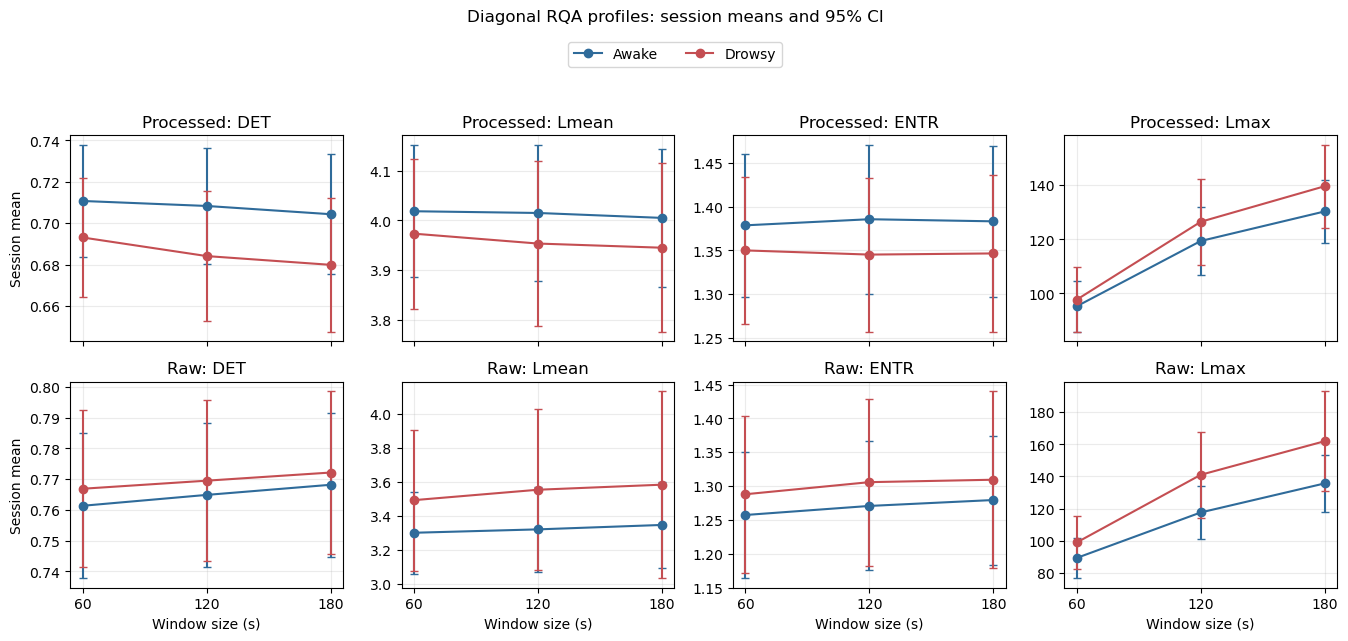

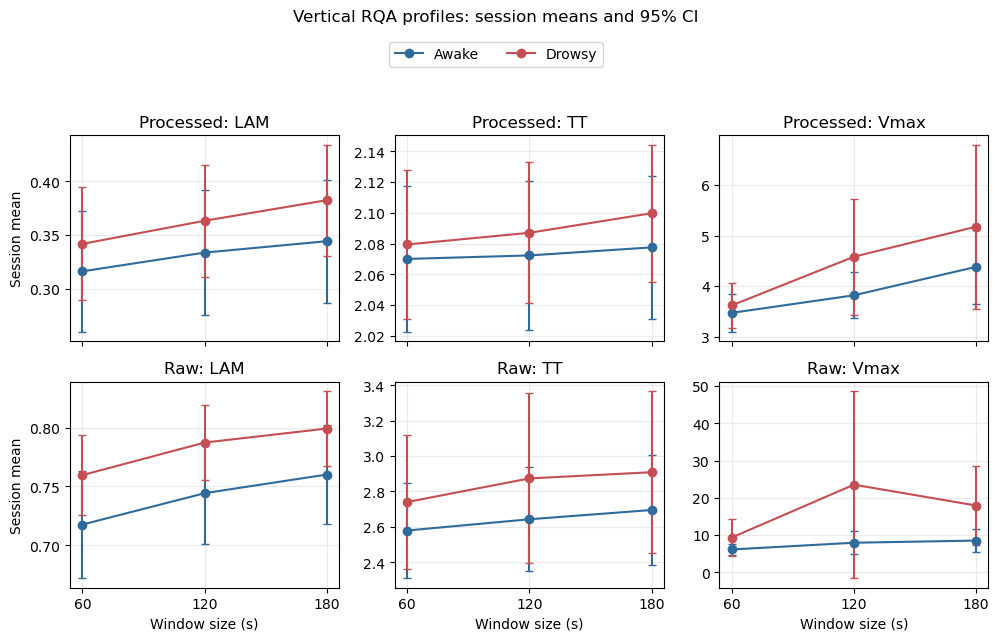

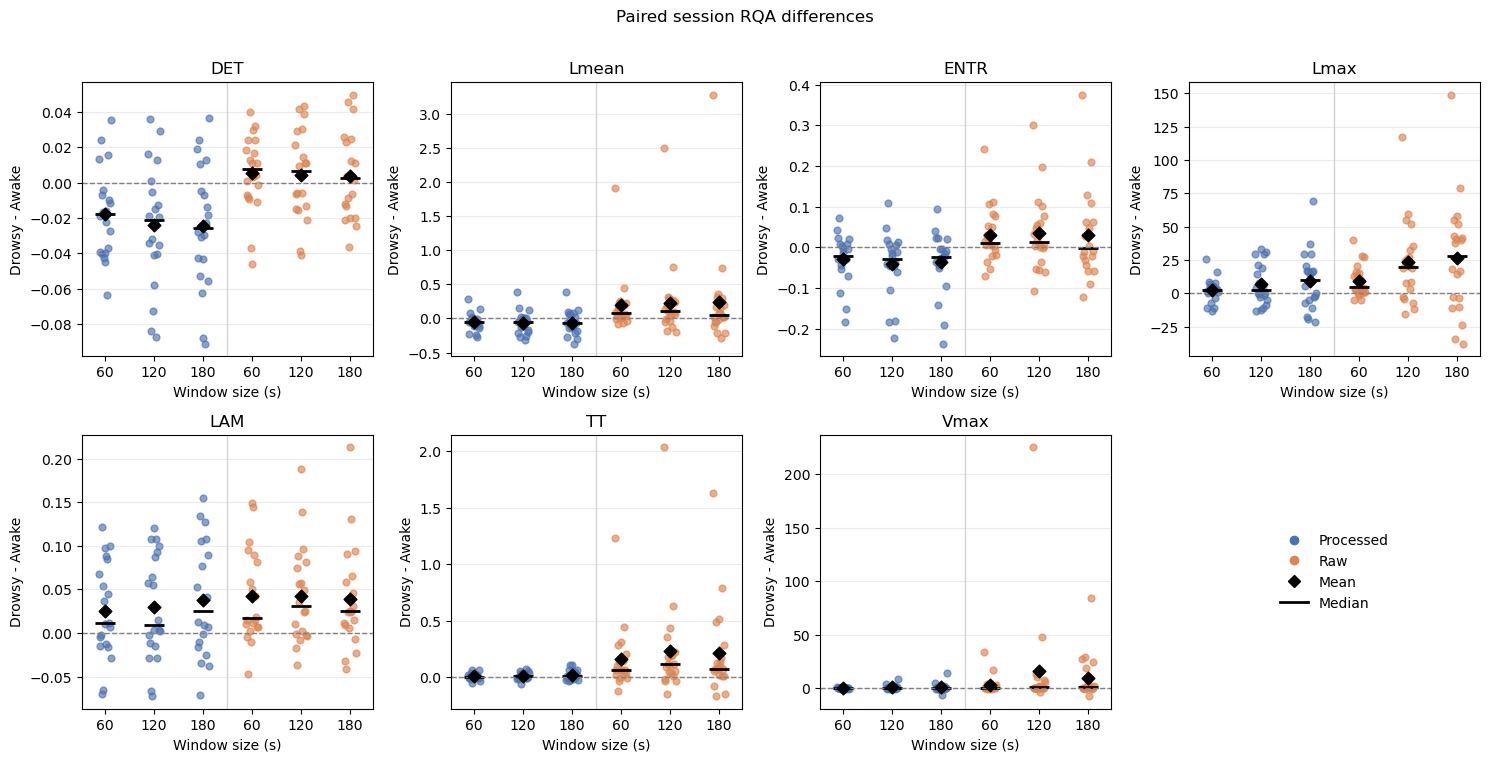

In [8]:
# Cell 8: Publication-ready RQ2 figures
from matplotlib.lines import Line2D

STATE_COLORS = {"Awake": "#2F6B9A", "Drowsy": "#C44E52"}
REPRESENTATION_COLORS = {"Processed": "#4C72B0", "Raw": "#DD8452"}


def plot_state_profiles(metrics, output_path, title):
    """Plot session-mean state profiles with 95% confidence intervals."""
    figure, axes = plt.subplots(
        len(REPRESENTATIONS),
        len(metrics),
        figsize=(3.4 * len(metrics), 6.4),
        squeeze=False,
        sharex=True,
    )
    for row, representation in enumerate(REPRESENTATIONS):
        for column, metric in enumerate(metrics):
            axis = axes[row, column]
            subset = session_summary.loc[
                session_summary["representation"] == representation
            ]
            for state in STATES:
                state_data = subset.loc[subset["state"] == state]
                statistics = (
                    state_data.groupby("window_size")[f"{metric}_mean"]
                    .agg(["mean", "std", "count"])
                    .reindex(WINDOW_SIZES)
                )
                confidence = (
                    1.96
                    * statistics["std"]
                    / np.sqrt(statistics["count"])
                )
                axis.errorbar(
                    WINDOW_SIZES,
                    statistics["mean"],
                    yerr=confidence,
                    marker="o",
                    capsize=3,
                    color=STATE_COLORS[state],
                    label=state,
                )
            axis.set_title(f"{representation}: {metric}")
            axis.set_xticks(WINDOW_SIZES)
            axis.grid(alpha=0.25)
            if row == len(REPRESENTATIONS) - 1:
                axis.set_xlabel("Window size (s)")
            if column == 0:
                axis.set_ylabel("Session mean")

    handles = [
        Line2D(
            [0],
            [0],
            color=STATE_COLORS[state],
            marker="o",
            label=state,
        )
        for state in STATES
    ]
    figure.suptitle(title, y=0.995)
    figure.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=2,
    )
    figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.90))
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    return figure


def plot_paired_deltas(output_path):
    """Plot within-session Drowsy-Awake metric differences."""
    figure, axes = plt.subplots(2, 4, figsize=(15, 7.5))
    axes = axes.ravel()
    categories = [
        (representation, window_size)
        for representation in REPRESENTATIONS
        for window_size in WINDOW_SIZES
    ]

    for axis, metric in zip(axes, METRICS):
        for position, (representation, window_size) in enumerate(categories):
            selected = paired_deltas.loc[
                (paired_deltas["representation"] == representation)
                & (paired_deltas["window_size"] == window_size),
                f"delta_{metric}",
            ].dropna()
            jitter = np.linspace(-0.12, 0.12, max(len(selected), 1))
            axis.scatter(
                position + jitter[:len(selected)],
                selected,
                s=24,
                alpha=0.65,
                color=REPRESENTATION_COLORS[representation],
            )
            if not selected.empty:
                axis.scatter(
                    position,
                    selected.mean(),
                    marker="D",
                    s=42,
                    color="black",
                    zorder=3,
                )
                axis.hlines(
                    selected.median(),
                    position - 0.20,
                    position + 0.20,
                    color="black",
                    linewidth=2,
                )
        axis.axhline(0.0, color="gray", linestyle="--", linewidth=1)
        axis.set_title(metric)
        axis.set_xticks(range(len(categories)))
        axis.set_xticklabels(
            [str(item[1]) for item in categories],
        )
        axis.axvline(2.5, color="lightgray", linewidth=1)
        axis.set_xlabel("Window size (s)")
        axis.set_ylabel("Drowsy - Awake")
        axis.grid(axis="y", alpha=0.25)

    axes[-1].axis("off")
    legend = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            color=REPRESENTATION_COLORS[representation],
            label=representation,
        )
        for representation in REPRESENTATIONS
    ]
    legend.extend(
        [
            Line2D(
                [0],
                [0],
                marker="D",
                linestyle="none",
                color="black",
                label="Mean",
            ),
            Line2D(
                [0],
                [0],
                color="black",
                linewidth=2,
                label="Median",
            ),
        ]
    )
    axes[-1].legend(handles=legend, loc="center", frameon=False)
    figure.suptitle("Paired session RQA differences", y=1.01)
    figure.tight_layout()
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    return figure


diagonal_figure = plot_state_profiles(
    ("DET", "Lmean", "ENTR", "Lmax"),
    RESULTS_DIR / "fig_rqa_diagonal_rq2.png",
    "Diagonal RQA profiles: session means and 95% CI",
)
vertical_figure = plot_state_profiles(
    ("LAM", "TT", "Vmax"),
    RESULTS_DIR / "fig_rqa_vertical_rq2.png",
    "Vertical RQA profiles: session means and 95% CI",
)
delta_figure = plot_paired_deltas(
    RESULTS_DIR / "fig_rqa_paired_deltas_rq2.png"
)


In [9]:
# Cell 9: Final run summary
window_results = pd.read_csv(WINDOW_OUTPUT)
qc_summary = pd.read_csv(QC_OUTPUT)
paired_deltas = pd.read_csv(DELTA_OUTPUT)
rq2_summary = pd.read_csv(RQ2_OUTPUT)

run_status = pd.DataFrame(
    {
        "item": [
            "Total windows processed",
            "Processed windows",
            "Raw windows",
            "Invalid outputs",
            "Max achieved-RR error",
            "Zero diagonal support",
            "Zero vertical support",
        ],
        "value": [
            len(window_results),
            (window_results["representation"] == "Processed").sum(),
            (window_results["representation"] == "Raw").sum(),
            qc_summary["invalid_outputs"].sum(),
            qc_summary["max_rr_error"].max(),
            qc_summary["zero_diagonal_support"].sum(),
            qc_summary["zero_vertical_support"].sum(),
        ],
    }
)
paired_status = (
    paired_deltas.groupby(
        ["representation", "window_size"],
        observed=True,
    )["session"]
    .nunique()
    .rename("n_paired_sessions")
    .reset_index()
)

display(run_status)
display(paired_status)
display(rq2_summary)


,item,value
0,Total windows processed,3181.000000
1,Processed windows,1544.000000
2,Raw windows,1637.000000
3,Invalid outputs,0.000000
4,Max achieved-RR error,0.000003
5,Zero diagonal support,0.000000
6,Zero vertical support,0.000000


,representation,window_size,n_paired_sessions
0,Processed,60,20
1,Processed,120,20
2,Processed,180,20
3,Raw,60,20
4,Raw,120,20
5,Raw,180,20


,representation,window_size,metric,n_paired_sessions,mean_delta,std_delta,median_delta,q25_delta,q75_delta,n_delta_positive,fraction_delta_positive,min_delta,max_delta
0,Processed,60,DET,20,-0.017596,0.025648,-0.017633,-0.039160,-0.006310,4,0.20,-0.063879,0.035565
1,Processed,60,ENTR,20,-0.028736,0.062453,-0.020828,-0.044830,0.007644,7,0.35,-0.183220,0.072609
2,Processed,60,LAM,20,0.025538,0.055098,0.011393,-0.013088,0.071794,12,0.60,-0.069166,0.121901
3,Processed,60,Lmax,20,2.456423,9.109597,2.874172,-0.415463,6.151716,15,0.75,-13.506667,25.607143
4,Processed,60,Lmean,20,-0.045135,0.129765,-0.046670,-0.105685,0.001576,5,0.25,-0.279045,0.289376
5,Processed,60,TT,20,0.009418,0.027491,0.006216,-0.004087,0.019811,13,0.65,-0.049703,0.065178
6,Processed,60,Vmax,20,0.147043,0.477055,0.051667,-0.202971,0.410556,11,0.55,-0.535714,1.386905
7,Processed,120,DET,20,-0.024155,0.034507,-0.021227,-0.040734,-0.003723,5,0.25,-0.087171,0.036107
8,Processed,120,ENTR,20,-0.040513,0.080387,-0.029068,-0.050229,0.005953,6,0.30,-0.223714,0.109955
9,Processed,120,LAM,20,0.029614,0.060248,0.009144,-0.012592,0.089137,13,0.65,-0.072337,0.120480


# Tổng hợp kết quả RQA toàn bộ dataset

Kết quả dưới đây là mô tả RQA theo đơn vị session. Không có kiểm định suy
luận và windows không được xem là các quan sát độc lập.

## 1. Phạm vi và protocol

- Số session: **20**.
- Tổng số windows: **3,181**.
- Processed: **1,544** windows; Raw: **1,637**
  windows.
- Mỗi tổ hợp `representation × window size` có **20 paired
  sessions**.
- Fixed RR = **2%**, `m = 8`, `l_min = v_min = 2`.
- `tau_processed = 0.16 s`, `tau_raw = 0.20 s`.
- Raw dùng SQI-only và không lọc stationarity; Processed dùng SQI và
  Processed stationarity.

## 2. Full-dataset QC

| Chỉ tiêu | Kết quả |
|---|---:|
| Invalid outputs | 0 |
| Maximum absolute RR error | 3.230e-06 |
| Zero diagonal support | 0 |
| Zero vertical support | 0 |
| Full QC | PASS |

Fixed-RR giữ recurrence density tương đương giữa Raw và Processed theo
thiết kế. Không có window bị loại khỏi phân tích do thiếu diagonal hoặc
vertical line support.

## 3. Mean paired delta theo session

Quy ước: `delta = Drowsy - Awake`. Giá trị dương nghĩa là metric trung
bình cao hơn ở Drowsy; giá trị âm nghĩa là metric trung bình thấp hơn.

| Representation | Window | DET | Lmean | ENTR | Lmax | LAM | TT | Vmax |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Processed | 60 s | -0.0176 | -0.0451 | -0.0287 | 2.4564 | 0.0255 | 0.0094 | 0.1470 |
| Processed | 120 s | -0.0242 | -0.0615 | -0.0405 | 7.0999 | 0.0296 | 0.0147 | 0.7637 |
| Processed | 180 s | -0.0244 | -0.0600 | -0.0368 | 9.3179 | 0.0382 | 0.0222 | 0.7950 |
| Raw | 60 s | 0.0055 | 0.1924 | 0.0307 | 9.6051 | 0.0420 | 0.1609 | 3.2115 |
| Raw | 120 s | 0.0046 | 0.2338 | 0.0351 | 23.3605 | 0.0430 | 0.2309 | 15.5938 |
| Raw | 180 s | 0.0040 | 0.2375 | 0.0300 | 26.1965 | 0.0391 | 0.2136 | 9.4099 |

## 4. Tính nhất quán về dấu

Bảng dưới là tỷ lệ session có `delta > 0`.

| Representation | Window | DET | Lmean | ENTR | Lmax | LAM | TT | Vmax |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Processed | 60 s | 0.20 | 0.25 | 0.35 | 0.75 | 0.60 | 0.65 | 0.55 |
| Processed | 120 s | 0.25 | 0.35 | 0.30 | 0.60 | 0.65 | 0.60 | 0.60 |
| Processed | 180 s | 0.25 | 0.35 | 0.25 | 0.60 | 0.65 | 0.65 | 0.60 |
| Raw | 60 s | 0.65 | 0.75 | 0.70 | 0.85 | 0.85 | 0.80 | 0.85 |
| Raw | 120 s | 0.55 | 0.70 | 0.65 | 0.75 | 0.70 | 0.80 | 0.75 |
| Raw | 180 s | 0.55 | 0.65 | 0.50 | 0.65 | 0.80 | 0.85 | 0.65 |

## 5. Mô tả kết quả quan trọng

- Với **Processed**, mean delta của `DET`, `Lmean` và `ENTR` âm tại cả
  60, 120 và 180 s. Mean delta của `Lmax`, `LAM`, `TT` và `Vmax` dương
  tại cả ba window sizes.
- Với **Raw**, mean delta của cả bảy metrics dương tại cả ba window
  sizes. Mức tăng lớn nhất về trị tuyệt đối xuất hiện ở các metric phụ
  thuộc line cực đại, đặc biệt `Lmax` và `Vmax`.
- `LAM` có mean delta dương ở cả Raw và Processed tại mọi window size.
  Tỷ lệ session có delta dương nằm trong khoảng 0.60–0.65 với Processed
  và 0.70–0.85 với Raw.
- Processed và Raw thể hiện hướng khác nhau đối với nhóm `DET`, `Lmean`
  và `ENTR`: Processed có mean delta âm, trong khi Raw có mean delta
  dương. Đây là mô tả khác biệt theo representation, không phải kết quả
  kiểm định thống kê.
- Các kết quả trên là descriptive evidence cho RQ2 ở cấp session. Việc
  đánh giá statistical significance cần được thực hiện ở bước phân tích
  suy luận riêng.

## 6. Output đã lưu

- `rqa_window_level.csv`
- `rqa_qc_summary.csv`
- `rqa_session_state_summary.csv`
- `rqa_session_paired_deltas.csv`
- `rqa_rq2_summary.csv`
- `fig_rqa_diagonal_rq2.png`
- `fig_rqa_vertical_rq2.png`
- `fig_rqa_paired_deltas_rq2.png`


## Kết luận thực nghiệm RQA và định hướng tiếp theo

### 1. Trạng thái phương pháp

RQA core đã được **validated và freeze** trên toàn bộ protocol:

- Phase-space reconstruction: `m = 8`.
- Delay: Processed `tau = 0.16 s`; Raw `tau = 0.20 s`.
- Theiler window: `W = (m - 1) * tau`.
- Distance: Euclidean.
- Threshold strategy: **Fixed Recurrence Rate = 2%**.
- Minimum line lengths: `l_min = v_min = 2`.
- RQA metrics:
  - Diagonal: `DET`, `Lmean`, `ENTR`, `Lmax`.
  - Vertical: `LAM`, `TT`, `Vmax`.

Full-dataset run gồm **20 sessions và 3,181 windows**, không có invalid output, không mất diagonal/vertical support và achieved RR bám target 2% trên toàn bộ dữ liệu. Do đó, các kết quả tiếp theo có thể được xem là output của một RQA protocol đã cố định, không phải kết quả của parameter tuning trên full dataset.

---

### 2. Kết luận mô tả chính cho RQ2

RQA cho thấy Awake và Drowsy không chỉ khác nhau về mức độ recurrence mà quan trọng hơn là **khác nhau về cách recurrence được tổ chức trong reconstructed phase space**.

#### Processed PPG

Drowsy có xu hướng:

- `DET ↓`
- `Lmean ↓`
- `ENTR ↓`

nhưng:

- `LAM ↑`
- `Lmax ↑`
- `TT` tăng nhẹ
- `Vmax ↑`

Pattern này nhất quán về hướng trên các cửa sổ 60, 120 và 180 s.

Điều này gợi ý rằng trong Processed PPG, Drowsy có thể liên quan đến:

> giảm coherence của recurrent trajectory evolution điển hình, đồng thời tăng các episode mang tính laminar/trapping hoặc các recurrence structures kéo dài cục bộ.

Diễn giải này phù hợp với quan sát trực quan rằng reconstructed trajectory ở Drowsy có xu hướng dày/phân tán hơn, đồng thời phù hợp với Simplex Prediction trước đó cho thấy forecast skill giảm trong Drowsy.

#### Raw PPG

Ở Raw PPG, cả bảy RQA metrics có mean paired delta dương trên cả 60, 120 và 180 s.

Đặc biệt:

- `LAM ↑`
- `TT ↑`
- `Lmean ↑`
- `ENTR ↑`

và các extreme metrics `Lmax`, `Vmax` cũng tăng rõ.

Điều này cho thấy Raw PPG bảo tồn một dạng state-dependent recurrence organization khác Processed PPG, đặc biệt liên quan đến slow/laminar dynamics và persistence trong phase space.

Do RR đã được cố định ở 2%, khác biệt Raw–Processed này không thể được giải thích đơn giản bởi một RP có mật độ recurrence lớn hơn RP kia.

---

### 3. Insight quan trọng về representation

RQA cung cấp bằng chứng rằng preprocessing không chỉ thay đổi chất lượng tín hiệu mà còn thay đổi **khía cạnh của dynamics có thể quan sát được**.

Một pattern đáng chú ý đang xuất hiện:

- **Processed PPG:** thể hiện rõ giảm local predictability và diagonal recurrence coherence trong Drowsy.
- **Raw PPG:** thể hiện mạnh hơn sự gia tăng recurrence persistence và laminar/trapping organization.

Do đó Raw và Processed không nhất thiết là hai representation cạnh tranh nhau; chúng có thể cung cấp **các góc nhìn động lực học bổ sung**.

Một giả thuyết khoa học tiềm năng là:

> Preprocessing modifies the observability of state-dependent nonlinear dynamics, suppressing slow amplitude/baseline components while retaining local pulsatile dynamics.

Điều này cần được kiểm tra bằng inference và surrogate analysis trước khi trở thành kết luận chính thức.

---

### 4. Insight về window length và tiềm năng engineering

Các paired RQA differences nhìn chung giữ cùng hướng trên:

`60 s → 120 s → 180 s`.

Đặc biệt, các metric bulk như:

- `DET`
- `Lmean`
- `ENTR`
- `LAM`
- `TT`

đã biểu hiện state-dependent pattern ngay từ cửa sổ 60 s.

Các cửa sổ dài hơn không tạo ra thay đổi rõ về hướng của dynamical signature, trong khi các extreme metrics (`Lmax`, `Vmax`) có variability lớn hơn khi window tăng.

Pattern tương tự cũng đã xuất hiện trong nonlinear prediction.

Do đó có một giả thuyết engineering đáng kiểm tra:

> **60 s có thể là observation window thực dụng để thu được phần lớn state-dependent nonlinear dynamical information, với latency và computational cost thấp hơn đáng kể so với 120–180 s.**

Hiện tại đây mới là descriptive insight; để gọi 60 s là *sufficient*, *equivalent* hoặc *non-inferior* cần một phân tích riêng ở cấp session.

---

### 5. Contribution khoa học hiện tại của RQA

Ở trạng thái hiện tại, RQA cung cấp **descriptive NTSA evidence thứ hai cho RQ2**, độc lập và bổ sung cho Simplex Prediction.

Hai phương pháp đang quan sát các mặt khác nhau của dynamics:

- **Simplex Prediction:** local temporal evolution / forecastability.
- **RQA:** recurrent geometry, trajectory organization và laminar persistence.

Do đó contribution tiềm năng không phải là một metric RQA đơn lẻ, mà là bằng chứng hội tụ rằng:

> **Awake và Drowsy biểu hiện các tổ chức động lực học khác nhau trong reconstructed PPG state space, và biểu hiện của sự khác biệt này phụ thuộc vào signal representation.**

Chưa được phép từ RQA alone kết luận:

- determinism,
- chaos,
- chaos-to-chaos transition.

---

### 6. Các bước tiếp theo để chuyển từ descriptive result thành scientific contribution

#### Step 1 — Session-level inferential analysis cho RQ2

Sử dụng `rqa_session_paired_deltas.csv` để đánh giá:

- paired Awake–Drowsy effects;
- effect sizes;
- confidence intervals;
- sign consistency;
- correction cho multiple comparisons.

Inference phải giữ `session` là đơn vị thống kê.

#### Step 2 — Kiểm tra robustness theo window size

Đánh giá trực tiếp:

`60 s vs 120 s vs 180 s`

trên session-level state effects.

Mục tiêu là xác định liệu 60 s có bảo tồn effect magnitude/direction đủ tốt để hỗ trợ một claim về shorter-window deployment.

#### Step 3 — Cross-representation analysis

Định lượng trực tiếp sự khác biệt:

`Raw state effect vs Processed state effect`

thay vì chỉ mô tả hai representation riêng biệt.

Điều này sẽ trực tiếp trả lời phần representation-dependent của RQ2/RQ3.

#### Step 4 — Surrogate testing cho RQ1

Sau khi Prediction và RQA đều đã freeze:

`Original window → Prediction + RQA`

so với:

`Surrogate ensemble → cùng frozen Prediction + RQA`.

Chỉ surrogate framework mới cho phép đánh giá liệu các cấu trúc prediction/recurrence quan sát được có vượt khỏi stochastic hoặc pseudoperiodic null phù hợp hay không.

---

### 7. Working interpretation

Ở thời điểm hiện tại, kết luận an toàn nhất là:

> **Drowsiness is associated with a systematic and representation-dependent reorganization of reconstructed PPG dynamics. Processed PPG shows reduced typical diagonal recurrence organization together with increased laminar structure, whereas Raw PPG shows broader increases in recurrence persistence and laminar organization. These patterns are directionally robust across 60–180 s windows and provide complementary nonlinear dynamical evidence to the previously observed changes in prediction skill.**

Đây là working interpretation cho RQ2 và sẽ được nâng cấp thành kết luận khoa học chính thức sau session-level inference, window-length robustness analysis và surrogate testing.

# RQ2 inferential integration

In [1]:
# RQ2 inference cell 1: Load and validate session-level data
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D


def find_project_root():
    """Locate the repository root."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "phase1" / "results" / "rqa").is_dir():
            return candidate
    raise FileNotFoundError("Cannot locate the project root.")


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "phase1" / "results" / "rqa"
STATE_INPUT = RESULTS_DIR / "rqa_session_state_summary.csv"
DELTA_INPUT = RESULTS_DIR / "rqa_session_paired_deltas.csv"

METRICS = ("DET", "Lmean", "ENTR", "Lmax", "LAM", "TT", "Vmax")
REPRESENTATIONS = ("Processed", "Raw")
WINDOW_SIZES = (60, 120, 180)
STATES = ("Awake", "Drowsy")
N_SESSIONS = 20
ALPHA = 0.05
RANDOM_SEED = 20260824
BOOTSTRAP_RESAMPLES = 20_000
PERMUTATION_BATCH = 65_536

state_summary = pd.read_csv(STATE_INPUT)
paired_deltas = pd.read_csv(DELTA_INPUT)
state_keys = ["session", "representation", "state", "window_size"]
paired_keys = ["session", "representation", "window_size"]
delta_columns = [f"delta_{metric}" for metric in METRICS]
state_numeric = [
    "n_windows",
    *[f"{metric}_mean" for metric in METRICS],
]
paired_numeric = [
    column
    for column in paired_deltas.columns
    if column not in paired_keys
]

state_pair_counts = state_summary.groupby(
    paired_keys,
    observed=True,
).size()
expected_pairs = N_SESSIONS * len(REPRESENTATIONS) * len(WINDOW_SIZES)

checks = {
    "20 sessions": state_summary["session"].nunique() == N_SESSIONS,
    "Representations complete": set(state_summary["representation"])
    == set(REPRESENTATIONS),
    "Window sizes complete": set(state_summary["window_size"])
    == set(WINDOW_SIZES),
    "States complete": set(state_summary["state"]) == set(STATES),
    "Session-state rows complete": len(state_summary)
    == expected_pairs * len(STATES),
    "Paired rows complete": len(paired_deltas) == expected_pairs,
    "Awake-Drowsy pairing complete": (state_pair_counts == 2).all(),
    "State duplicates": not state_summary.duplicated(state_keys).any(),
    "Paired duplicates": not paired_deltas.duplicated(paired_keys).any(),
    "Inference state values finite": np.isfinite(
        state_summary[state_numeric].to_numpy(dtype=float)
    ).all(),
    "Paired values finite": np.isfinite(
        paired_deltas[paired_numeric].to_numpy(dtype=float)
    ).all(),
    "Seven delta metrics": set(delta_columns).issubset(
        paired_deltas.columns
    ),
}

state_wide = state_summary.pivot(
    index=paired_keys,
    columns="state",
    values=[f"{metric}_mean" for metric in METRICS],
)
delta_match = True
indexed_deltas = paired_deltas.set_index(paired_keys)
for metric in METRICS:
    direct_delta = (
        state_wide[(f"{metric}_mean", "Drowsy")]
        - state_wide[(f"{metric}_mean", "Awake")]
    )
    stored_delta = indexed_deltas[f"delta_{metric}"].reindex(
        direct_delta.index
    )
    delta_match &= np.allclose(direct_delta, stored_delta)
checks["Stored deltas match state means"] = delta_match

coverage = (
    paired_deltas.groupby(
        ["representation", "window_size"],
        observed=True,
    )
    .agg(
        n_sessions=("session", "nunique"),
        n_paired_rows=("session", "size"),
    )
    .reset_index()
)
qc_table = pd.DataFrame(
    {
        "check": checks.keys(),
        "status": ["PASS" if value else "FAIL" for value in checks.values()],
    }
)
display(coverage)
display(qc_table)

if not all(checks.values()):
    raise RuntimeError("Session-level inference input QC failed.")

print("Session-level inference input QC: PASS")


,representation,window_size,n_sessions,n_paired_rows
0,Processed,60,20,20
1,Processed,120,20,20
2,Processed,180,20,20
3,Raw,60,20,20
4,Raw,120,20,20
5,Raw,180,20,20


,check,status
0,20 sessions,PASS
1,Representations complete,PASS
2,Window sizes complete,PASS
3,States complete,PASS
4,Session-state rows complete,PASS
5,Paired rows complete,PASS
6,Awake-Drowsy pairing complete,PASS
7,State duplicates,PASS
8,Paired duplicates,PASS
9,Inference state values finite,PASS


Session-level inference input QC: PASS


In [2]:
# RQ2 inference cell 2: Primary Awake-Drowsy inference
STATE_INFERENCE_OUTPUT = RESULTS_DIR / "rqa_state_inference.csv"


def bootstrap_mean_ci(values, rng):
    """Estimate a percentile bootstrap CI for the mean."""
    values = np.asarray(values, dtype=float)
    means = np.empty(BOOTSTRAP_RESAMPLES, dtype=float)
    batch_size = 2_000
    for start in range(0, BOOTSTRAP_RESAMPLES, batch_size):
        stop = min(start + batch_size, BOOTSTRAP_RESAMPLES)
        indices = rng.integers(
            0,
            values.size,
            size=(stop - start, values.size),
        )
        means[start:stop] = values[indices].mean(axis=1)
    return tuple(np.quantile(means, [ALPHA / 2, 1 - ALPHA / 2]))


def sign_flip_pvalue(values):
    """Compute an exact two-sided paired sign-flip p-value."""
    values = np.asarray(values, dtype=float)
    n_values = values.size
    n_permutations = 1 << n_values
    observed = abs(values.mean())
    tolerance = np.finfo(float).eps * max(1.0, observed)
    exceedances = 0
    bit_positions = np.arange(n_values, dtype=np.uint64)

    for start in range(0, n_permutations, PERMUTATION_BATCH):
        stop = min(start + PERMUTATION_BATCH, n_permutations)
        integers = np.arange(start, stop, dtype=np.uint64)[:, None]
        signs = 1.0 - 2.0 * ((integers >> bit_positions) & 1)
        permuted = np.abs(signs @ values / n_values)
        exceedances += int(np.count_nonzero(permuted >= observed - tolerance))
    return exceedances / n_permutations


def benjamini_hochberg(p_values):
    """Adjust one predefined p-value family with BH-FDR."""
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    ranked = p_values[order]
    adjusted = ranked * p_values.size / np.arange(1, p_values.size + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    result = np.empty_like(adjusted)
    result[order] = np.clip(adjusted, 0.0, 1.0)
    return result


rng = np.random.default_rng(RANDOM_SEED)
state_records = []
for representation in REPRESENTATIONS:
    for window_size in WINDOW_SIZES:
        selected = paired_deltas.loc[
            (paired_deltas["representation"] == representation)
            & (paired_deltas["window_size"] == window_size)
        ].sort_values("session")
        for metric in METRICS:
            values = selected[f"delta_{metric}"].to_numpy(dtype=float)
            mean_delta = values.mean()
            sd_delta = values.std(ddof=1)
            ci_low, ci_high = bootstrap_mean_ci(values, rng)
            effect_size = mean_delta / sd_delta if sd_delta > 0 else 0.0
            state_records.append(
                {
                    "representation": representation,
                    "window_size": window_size,
                    "metric": metric,
                    "n_paired_sessions": values.size,
                    "mean_delta": mean_delta,
                    "sd_delta": sd_delta,
                    "median_delta": np.median(values),
                    "ci_low": ci_low,
                    "ci_high": ci_high,
                    "effect_size_dz": effect_size,
                    "fraction_delta_positive": np.mean(values > 0),
                    "raw_p": sign_flip_pvalue(values),
                }
            )

state_inference = pd.DataFrame.from_records(state_records)
state_inference["fdr_q"] = benjamini_hochberg(
    state_inference["raw_p"]
)
state_inference["fdr_significant"] = state_inference["fdr_q"] < ALPHA
state_inference.to_csv(STATE_INFERENCE_OUTPUT, index=False)
display(state_inference)
print(
    "BH-FDR-supported state effects: "
    f"{int(state_inference['fdr_significant'].sum())}/42"
)


,representation,window_size,metric,n_paired_sessions,mean_delta,sd_delta,median_delta,ci_low,ci_high,effect_size_dz,fraction_delta_positive,raw_p,fdr_q,fdr_significant
0,Processed,60,DET,20,-0.017596,0.025648,-0.017633,-0.028416,-0.006422,-0.686072,0.20,0.007359,0.023774,True
1,Processed,60,Lmean,20,-0.045135,0.129765,-0.046670,-0.099612,0.011407,-0.347822,0.25,0.137117,0.169380,False
2,Processed,60,ENTR,20,-0.028736,0.062453,-0.020828,-0.056746,-0.003689,-0.460124,0.35,0.051384,0.086715,False
3,Processed,60,Lmax,20,2.456423,9.109597,2.874172,-1.402960,6.429755,0.269652,0.75,0.247803,0.281290,False
4,Processed,60,LAM,20,0.025538,0.055098,0.011393,0.002507,0.048927,0.463509,0.60,0.052822,0.086715,False
5,Processed,60,TT,20,0.009418,0.027491,0.006216,-0.002346,0.021248,0.342597,0.65,0.143660,0.172392,False
6,Processed,60,Vmax,20,0.147043,0.477055,0.051667,-0.047732,0.356893,0.308231,0.55,0.186661,0.217771,False
7,Processed,120,DET,20,-0.024155,0.034507,-0.021227,-0.039043,-0.009436,-0.699985,0.25,0.005507,0.021025,True
8,Processed,120,Lmean,20,-0.061508,0.163147,-0.056340,-0.128380,0.010816,-0.377012,0.35,0.108393,0.143645,False
9,Processed,120,ENTR,20,-0.040513,0.080387,-0.029068,-0.075982,-0.008078,-0.503972,0.30,0.034979,0.073456,False


BH-FDR-supported state effects: 17/42


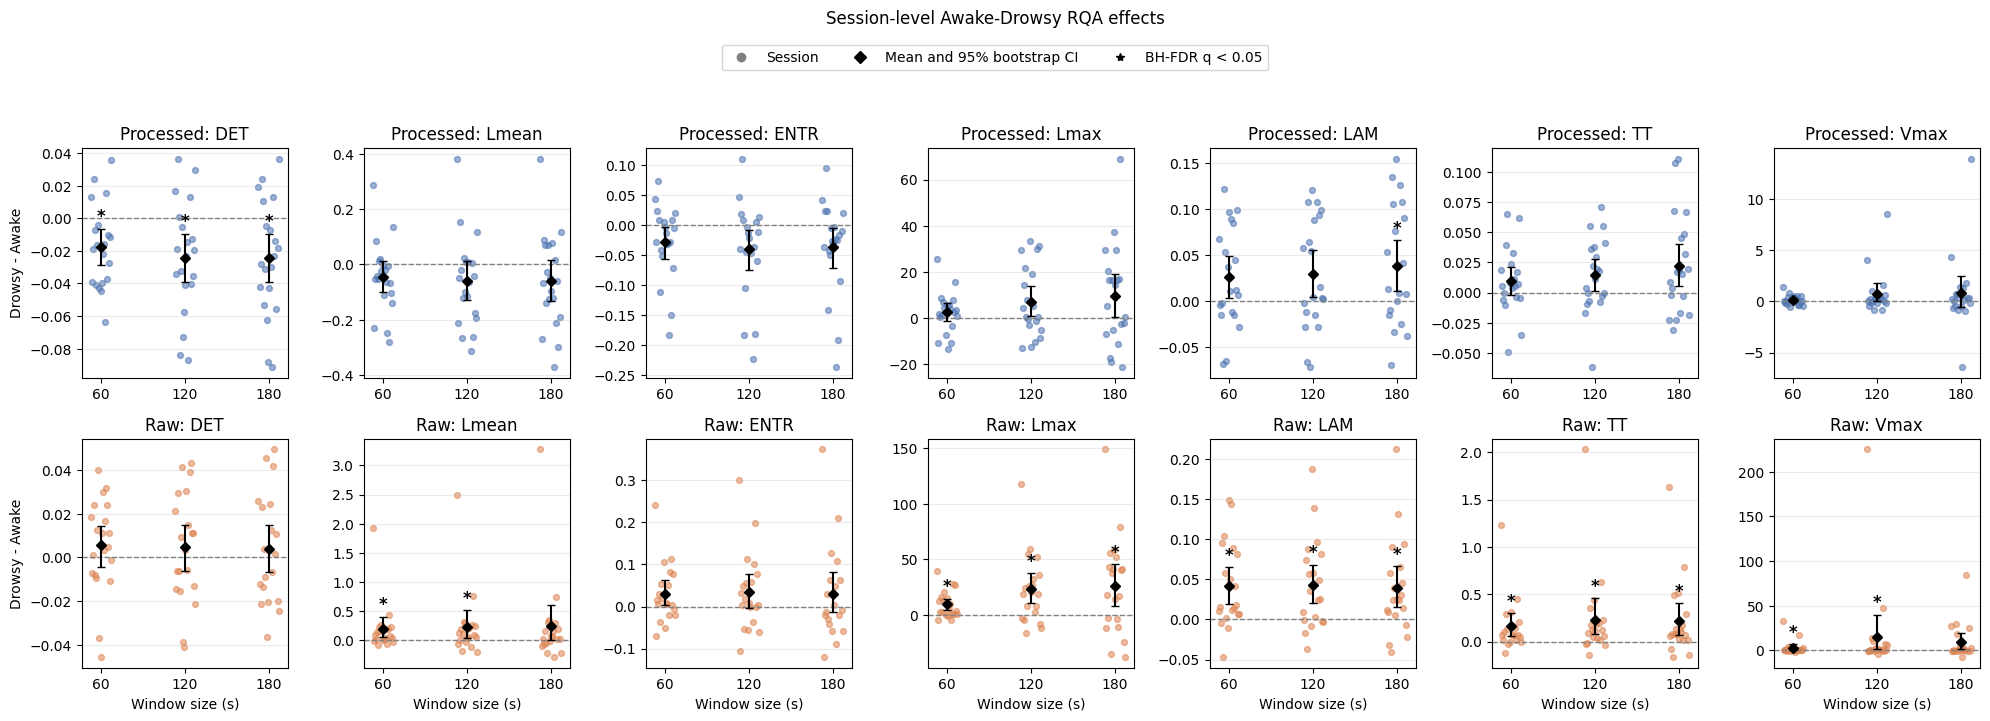

In [3]:
# RQ2 inference cell 3: State-effect visualization
STATE_FIGURE_PNG = RESULTS_DIR / "fig_rqa_state_inference.png"
STATE_FIGURE_PDF = RESULTS_DIR / "fig_rqa_state_inference.pdf"
REPRESENTATION_COLORS = {"Processed": "#4C72B0", "Raw": "#DD8452"}

figure, axes = plt.subplots(
    len(REPRESENTATIONS),
    len(METRICS),
    figsize=(20, 7.2),
    squeeze=False,
)

for row, representation in enumerate(REPRESENTATIONS):
    color = REPRESENTATION_COLORS[representation]
    for column, metric in enumerate(METRICS):
        axis = axes[row, column]
        for position, window_size in enumerate(WINDOW_SIZES):
            values = paired_deltas.loc[
                (paired_deltas["representation"] == representation)
                & (paired_deltas["window_size"] == window_size),
                f"delta_{metric}",
            ].sort_index()
            jitter = np.linspace(-0.12, 0.12, len(values))
            axis.scatter(
                position + jitter,
                values,
                s=18,
                alpha=0.55,
                color=color,
            )
            result = state_inference.loc[
                (state_inference["representation"] == representation)
                & (state_inference["window_size"] == window_size)
                & (state_inference["metric"] == metric)
            ].iloc[0]
            lower = result["mean_delta"] - result["ci_low"]
            upper = result["ci_high"] - result["mean_delta"]
            axis.errorbar(
                position,
                result["mean_delta"],
                yerr=[[lower], [upper]],
                marker="D",
                markersize=5,
                capsize=3,
                color="black",
                zorder=3,
            )
            if result["fdr_significant"]:
                axis.annotate(
                    "*",
                    (position, result["ci_high"]),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha="center",
                    fontsize=12,
                    fontweight="bold",
                )
        axis.axhline(0.0, color="gray", linestyle="--", linewidth=1)
        axis.set_xticks(range(len(WINDOW_SIZES)), WINDOW_SIZES)
        axis.set_title(f"{representation}: {metric}")
        axis.grid(axis="y", alpha=0.25)
        if row == len(REPRESENTATIONS) - 1:
            axis.set_xlabel("Window size (s)")
        if column == 0:
            axis.set_ylabel("Drowsy - Awake")

legend = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        color="gray",
        label="Session",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="none",
        color="black",
        label="Mean and 95% bootstrap CI",
    ),
    Line2D(
        [0],
        [0],
        marker="*",
        linestyle="none",
        color="black",
        label="BH-FDR q < 0.05",
    ),
]
figure.suptitle("Session-level Awake-Drowsy RQA effects", y=0.995)
figure.legend(
    handles=legend,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=3,
)
figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.90))
figure.savefig(STATE_FIGURE_PNG, dpi=300, bbox_inches="tight")
figure.savefig(STATE_FIGURE_PDF, bbox_inches="tight")


In [4]:
# RQ2 inference cell 4: Window-length robustness
ROBUSTNESS_OUTPUT = RESULTS_DIR / "rqa_window_robustness.csv"


def pearson_correlation(first, second):
    """Compute Pearson correlation for nonconstant paired values."""
    if np.std(first, ddof=1) == 0 or np.std(second, ddof=1) == 0:
        return np.nan
    return float(np.corrcoef(first, second)[0, 1])


rng = np.random.default_rng(RANDOM_SEED + 1)
robustness_records = []
for representation in REPRESENTATIONS:
    representation_data = paired_deltas.loc[
        paired_deltas["representation"] == representation
    ]
    for metric in METRICS:
        wide = representation_data.pivot(
            index="session",
            columns="window_size",
            values=f"delta_{metric}",
        ).reindex(columns=WINDOW_SIZES)
        delta_60 = wide[60].to_numpy(dtype=float)
        delta_120 = wide[120].to_numpy(dtype=float)
        delta_180 = wide[180].to_numpy(dtype=float)
        difference_120 = delta_120 - delta_60
        difference_180 = delta_180 - delta_60
        ci_120 = bootstrap_mean_ci(difference_120, rng)
        ci_180 = bootstrap_mean_ci(difference_180, rng)
        mean_deltas = np.array(
            [delta_60.mean(), delta_120.mean(), delta_180.mean()]
        )
        direction_preserved = bool(
            np.all(mean_deltas > 0) or np.all(mean_deltas < 0)
        )
        robustness_records.append(
            {
                "representation": representation,
                "metric": metric,
                "n_paired_sessions": len(wide),
                "mean_delta_60": delta_60.mean(),
                "median_delta_60": np.median(delta_60),
                "mean_delta_120": delta_120.mean(),
                "median_delta_120": np.median(delta_120),
                "mean_delta_180": delta_180.mean(),
                "median_delta_180": np.median(delta_180),
                "mean_difference_120_60": difference_120.mean(),
                "ci_low_difference_120_60": ci_120[0],
                "ci_high_difference_120_60": ci_120[1],
                "mean_difference_180_60": difference_180.mean(),
                "ci_low_difference_180_60": ci_180[0],
                "ci_high_difference_180_60": ci_180[1],
                "pearson_r_60_120": pearson_correlation(
                    delta_60,
                    delta_120,
                ),
                "pearson_r_60_180": pearson_correlation(
                    delta_60,
                    delta_180,
                ),
                "sign_agreement_60_120": np.mean(
                    np.sign(delta_60) == np.sign(delta_120)
                ),
                "sign_agreement_60_180": np.mean(
                    np.sign(delta_60) == np.sign(delta_180)
                ),
                "directionally_preserved": direction_preserved,
            }
        )

window_robustness = pd.DataFrame.from_records(robustness_records)
window_robustness.to_csv(ROBUSTNESS_OUTPUT, index=False)
display(window_robustness)


,representation,metric,n_paired_sessions,mean_delta_60,median_delta_60,mean_delta_120,median_delta_120,mean_delta_180,median_delta_180,mean_difference_120_60,ci_low_difference_120_60,ci_high_difference_120_60,mean_difference_180_60,ci_low_difference_180_60,ci_high_difference_180_60,pearson_r_60_120,pearson_r_60_180,sign_agreement_60_120,sign_agreement_60_180,directionally_preserved
0,Processed,DET,20,-0.017596,-0.017633,-0.024155,-0.021227,-0.024400,-0.025515,-0.006558,-0.012607,-0.001315,-0.006804,-0.013456,-0.000347,0.946129,0.925553,0.95,0.95,True
1,Processed,Lmean,20,-0.045135,-0.046670,-0.061508,-0.056340,-0.059999,-0.063293,-0.016373,-0.048314,0.011588,-0.014864,-0.049050,0.017705,0.911487,0.903513,0.80,0.80,True
2,Processed,ENTR,20,-0.028736,-0.020828,-0.040513,-0.029068,-0.036780,-0.024461,-0.011777,-0.022528,-0.001888,-0.008043,-0.016872,0.000310,0.973106,0.982769,0.95,0.90,True
3,Processed,Lmax,20,2.456423,2.874172,7.099891,2.205357,9.317931,9.844048,4.643468,0.641372,8.945599,6.861508,-2.264194,16.275007,0.797280,0.260301,0.85,0.65,True
4,Processed,LAM,20,0.025538,0.011393,0.029614,0.009144,0.038183,0.025355,0.004076,-0.002769,0.011871,0.012644,-0.000090,0.025275,0.960681,0.894710,0.95,0.85,True
5,Processed,TT,20,0.009418,0.006216,0.014709,0.014521,0.022220,0.016184,0.005291,-0.004344,0.016480,0.012802,0.000312,0.025498,0.646081,0.706905,0.85,0.80,True
6,Processed,Vmax,20,0.147043,0.051667,0.763666,0.238095,0.795049,0.288961,0.616623,-0.065753,1.682157,0.648005,-0.701410,2.437439,0.045559,-0.070785,0.75,0.60,True
7,Raw,DET,20,0.005548,0.007908,0.004632,0.006428,0.003989,0.002652,-0.000916,-0.004313,0.002528,-0.001560,-0.007806,0.004693,0.951258,0.814928,0.90,0.80,True
8,Raw,Lmean,20,0.192364,0.081830,0.233752,0.103913,0.237519,0.047264,0.041388,-0.018739,0.117443,0.045155,-0.074642,0.212981,0.991022,0.981330,0.95,0.90,True
9,Raw,ENTR,20,0.030656,0.011927,0.035150,0.013316,0.030003,-0.002656,0.004494,-0.007834,0.018407,-0.000653,-0.022376,0.022404,0.971546,0.942210,0.85,0.80,True


In [5]:
# RQ2 inference cell 5: Cross-representation inference
REPRESENTATION_OUTPUT = (
    RESULTS_DIR / "rqa_representation_inference.csv"
)

rng = np.random.default_rng(RANDOM_SEED + 2)
representation_records = []
for window_size in WINDOW_SIZES:
    selected = paired_deltas.loc[
        paired_deltas["window_size"] == window_size
    ]
    for metric in METRICS:
        wide = selected.pivot(
            index="session",
            columns="representation",
            values=f"delta_{metric}",
        ).reindex(columns=REPRESENTATIONS)
        values = (
            wide["Raw"] - wide["Processed"]
        ).to_numpy(dtype=float)
        mean_difference = values.mean()
        sd_difference = values.std(ddof=1)
        ci_low, ci_high = bootstrap_mean_ci(values, rng)
        effect_size = (
            mean_difference / sd_difference
            if sd_difference > 0
            else 0.0
        )
        representation_records.append(
            {
                "window_size": window_size,
                "metric": metric,
                "n_paired_sessions": values.size,
                "mean_difference": mean_difference,
                "sd_difference": sd_difference,
                "median_difference": np.median(values),
                "ci_low": ci_low,
                "ci_high": ci_high,
                "effect_size_dz": effect_size,
                "fraction_difference_positive": np.mean(values > 0),
                "raw_p": sign_flip_pvalue(values),
            }
        )

representation_inference = pd.DataFrame.from_records(
    representation_records
)
representation_inference["fdr_q"] = benjamini_hochberg(
    representation_inference["raw_p"]
)
representation_inference["fdr_significant"] = (
    representation_inference["fdr_q"] < ALPHA
)
representation_inference.to_csv(REPRESENTATION_OUTPUT, index=False)
display(representation_inference)
print(
    "BH-FDR-supported representation differences: "
    f"{int(representation_inference['fdr_significant'].sum())}/21"
)


,window_size,metric,n_paired_sessions,mean_difference,sd_difference,median_difference,ci_low,ci_high,effect_size_dz,fraction_difference_positive,raw_p,fdr_q,fdr_significant
0,60,DET,20,0.023145,0.026901,0.019480,0.011570,0.034669,0.860374,0.80,0.001059,0.003914,True
1,60,Lmean,20,0.237499,0.373113,0.180315,0.108134,0.421071,0.636534,0.85,0.000217,0.002230,True
2,60,ENTR,20,0.059392,0.088690,0.056207,0.022542,0.098480,0.669653,0.65,0.006340,0.012198,True
3,60,Lmax,20,7.148684,5.888792,6.581019,4.684831,9.712140,1.213947,0.90,0.000025,0.000521,True
4,60,LAM,20,0.016486,0.036972,0.015026,0.000516,0.032343,0.445892,0.75,0.060362,0.066716,False
5,60,TT,20,0.151481,0.275382,0.062946,0.058346,0.285892,0.550077,0.90,0.000319,0.002230,True
6,60,Vmax,20,3.064414,7.866101,0.405827,0.431306,6.935787,0.389572,0.85,0.007153,0.012198,True
7,120,DET,20,0.028787,0.034380,0.025075,0.014167,0.043713,0.837313,0.85,0.001270,0.003914,True
8,120,Lmean,20,0.295260,0.499639,0.208548,0.117941,0.532713,0.590946,0.85,0.000870,0.003914,True
9,120,ENTR,20,0.075663,0.117321,0.070462,0.027293,0.127960,0.644921,0.75,0.007132,0.012198,True


BH-FDR-supported representation differences: 17/21


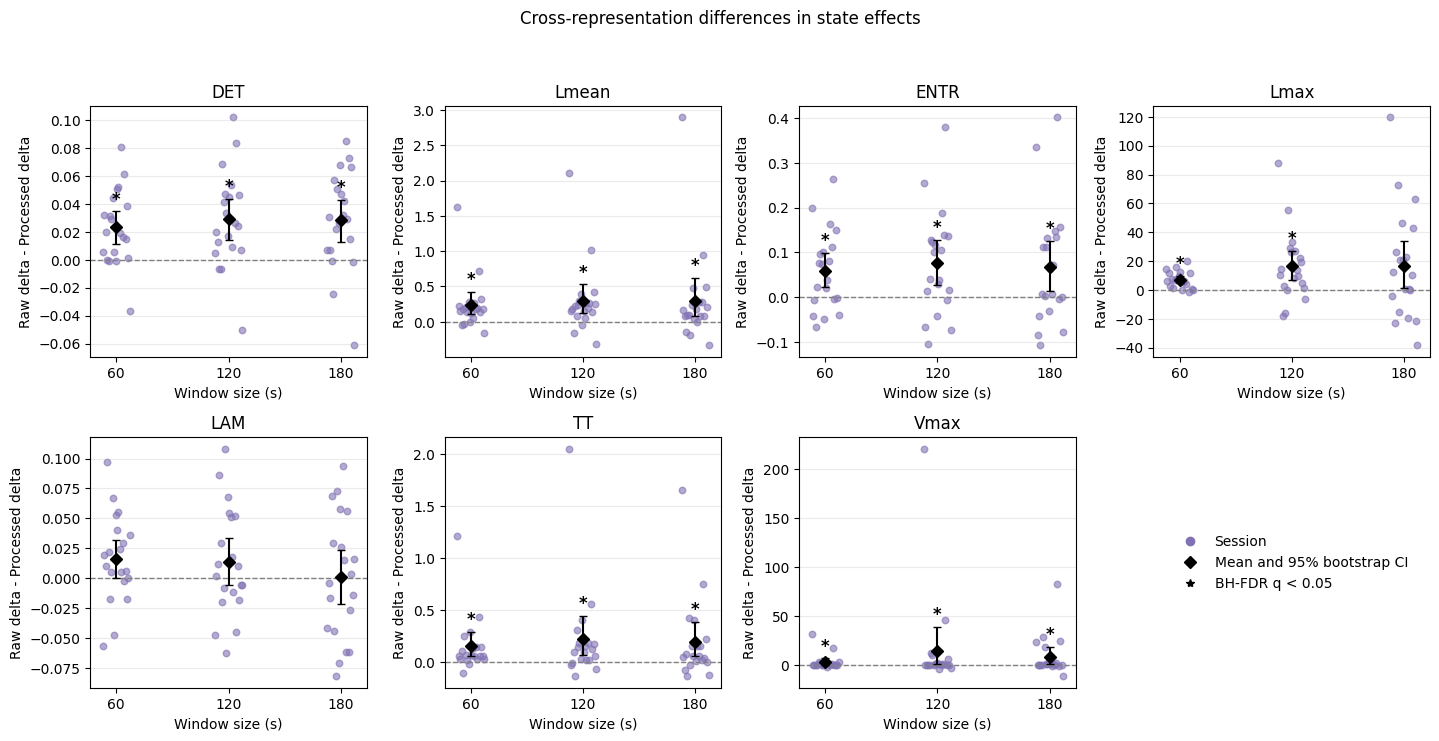

In [6]:
# RQ2 inference cell 6: Cross-representation visualization
REPRESENTATION_FIGURE_PNG = (
    RESULTS_DIR / "fig_rqa_representation_inference.png"
)
REPRESENTATION_FIGURE_PDF = (
    RESULTS_DIR / "fig_rqa_representation_inference.pdf"
)

figure, axes = plt.subplots(2, 4, figsize=(14.5, 7.4))
axes = axes.ravel()

for axis, metric in zip(axes, METRICS):
    for position, window_size in enumerate(WINDOW_SIZES):
        selected = paired_deltas.loc[
            paired_deltas["window_size"] == window_size
        ]
        wide = selected.pivot(
            index="session",
            columns="representation",
            values=f"delta_{metric}",
        ).reindex(columns=REPRESENTATIONS)
        values = wide["Raw"] - wide["Processed"]
        jitter = np.linspace(-0.12, 0.12, len(values))
        axis.scatter(
            position + jitter,
            values,
            s=22,
            alpha=0.60,
            color="#8172B3",
        )
        result = representation_inference.loc[
            (representation_inference["window_size"] == window_size)
            & (representation_inference["metric"] == metric)
        ].iloc[0]
        lower = result["mean_difference"] - result["ci_low"]
        upper = result["ci_high"] - result["mean_difference"]
        axis.errorbar(
            position,
            result["mean_difference"],
            yerr=[[lower], [upper]],
            marker="D",
            markersize=6,
            capsize=3,
            color="black",
            zorder=3,
        )
        if result["fdr_significant"]:
            axis.annotate(
                "*",
                (position, result["ci_high"]),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                fontsize=12,
                fontweight="bold",
            )
    axis.axhline(0.0, color="gray", linestyle="--", linewidth=1)
    axis.set_xticks(range(len(WINDOW_SIZES)), WINDOW_SIZES)
    axis.set_title(metric)
    axis.set_xlabel("Window size (s)")
    axis.set_ylabel("Raw delta - Processed delta")
    axis.grid(axis="y", alpha=0.25)

axes[-1].axis("off")
legend = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        color="#8172B3",
        label="Session",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="none",
        color="black",
        label="Mean and 95% bootstrap CI",
    ),
    Line2D(
        [0],
        [0],
        marker="*",
        linestyle="none",
        color="black",
        label="BH-FDR q < 0.05",
    ),
]
axes[-1].legend(handles=legend, loc="center", frameon=False)
figure.suptitle(
    "Cross-representation differences in state effects",
    y=0.995,
)
figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
figure.savefig(REPRESENTATION_FIGURE_PNG, dpi=300, bbox_inches="tight")
figure.savefig(REPRESENTATION_FIGURE_PDF, bbox_inches="tight")


In [7]:
# RQ2 inference cell 7: Integrated inferential summary
INTEGRATED_OUTPUT = RESULTS_DIR / "rqa_rq2_inferential_summary.csv"

integrated_summary = state_inference.copy()
integrated_summary["fraction_sessions_same_direction"] = np.where(
    integrated_summary["mean_delta"] >= 0,
    integrated_summary["fraction_delta_positive"],
    1.0 - integrated_summary["fraction_delta_positive"],
)
robustness_columns = window_robustness[
    ["representation", "metric", "directionally_preserved"]
].rename(
    columns={
        "directionally_preserved": "window_direction_robustness"
    }
)
cross_columns = representation_inference.rename(
    columns={
        "mean_difference": "cross_rep_mean_difference",
        "ci_low": "cross_rep_ci_low",
        "ci_high": "cross_rep_ci_high",
        "effect_size_dz": "cross_rep_effect_size_dz",
        "raw_p": "cross_rep_raw_p",
        "fdr_q": "cross_rep_fdr_q",
        "fdr_significant": "cross_rep_fdr_significant",
    }
)[
    [
        "window_size",
        "metric",
        "cross_rep_mean_difference",
        "cross_rep_ci_low",
        "cross_rep_ci_high",
        "cross_rep_effect_size_dz",
        "cross_rep_raw_p",
        "cross_rep_fdr_q",
        "cross_rep_fdr_significant",
    ]
]
integrated_summary = integrated_summary.merge(
    robustness_columns,
    on=["representation", "metric"],
    how="left",
    validate="many_to_one",
)
integrated_summary = integrated_summary.merge(
    cross_columns,
    on=["window_size", "metric"],
    how="left",
    validate="many_to_one",
)
integrated_summary = integrated_summary[
    [
        "representation",
        "window_size",
        "metric",
        "n_paired_sessions",
        "mean_delta",
        "ci_low",
        "ci_high",
        "effect_size_dz",
        "fraction_sessions_same_direction",
        "raw_p",
        "fdr_q",
        "fdr_significant",
        "window_direction_robustness",
        "cross_rep_mean_difference",
        "cross_rep_ci_low",
        "cross_rep_ci_high",
        "cross_rep_effect_size_dz",
        "cross_rep_raw_p",
        "cross_rep_fdr_q",
        "cross_rep_fdr_significant",
    ]
].sort_values(
    ["representation", "window_size", "metric"]
).reset_index(drop=True)
integrated_summary.to_csv(INTEGRATED_OUTPUT, index=False)
display(integrated_summary)


,representation,window_size,metric,n_paired_sessions,mean_delta,ci_low,ci_high,effect_size_dz,fraction_sessions_same_direction,raw_p,fdr_q,fdr_significant,window_direction_robustness,cross_rep_mean_difference,cross_rep_ci_low,cross_rep_ci_high,cross_rep_effect_size_dz,cross_rep_raw_p,cross_rep_fdr_q,cross_rep_fdr_significant
0,Processed,60,DET,20,-0.017596,-0.028416,-0.006422,-0.686072,0.80,0.007359,0.023774,True,True,0.023145,0.011570,0.034669,0.860374,0.001059,0.003914,True
1,Processed,60,ENTR,20,-0.028736,-0.056746,-0.003689,-0.460124,0.65,0.051384,0.086715,False,True,0.059392,0.022542,0.098480,0.669653,0.006340,0.012198,True
2,Processed,60,LAM,20,0.025538,0.002507,0.048927,0.463509,0.60,0.052822,0.086715,False,True,0.016486,0.000516,0.032343,0.445892,0.060362,0.066716,False
3,Processed,60,Lmax,20,2.456423,-1.402960,6.429755,0.269652,0.75,0.247803,0.281290,False,True,7.148684,4.684831,9.712140,1.213947,0.000025,0.000521,True
4,Processed,60,Lmean,20,-0.045135,-0.099612,0.011407,-0.347822,0.75,0.137117,0.169380,False,True,0.237499,0.108134,0.421071,0.636534,0.000217,0.002230,True
5,Processed,60,TT,20,0.009418,-0.002346,0.021248,0.342597,0.65,0.143660,0.172392,False,True,0.151481,0.058346,0.285892,0.550077,0.000319,0.002230,True
6,Processed,60,Vmax,20,0.147043,-0.047732,0.356893,0.308231,0.55,0.186661,0.217771,False,True,3.064414,0.431306,6.935787,0.389572,0.007153,0.012198,True
7,Processed,120,DET,20,-0.024155,-0.039043,-0.009436,-0.699985,0.75,0.005507,0.021025,True,True,0.028787,0.014167,0.043713,0.837313,0.001270,0.003914,True
8,Processed,120,ENTR,20,-0.040513,-0.075982,-0.008078,-0.503972,0.70,0.034979,0.073456,False,True,0.075663,0.027293,0.127960,0.644921,0.007132,0.012198,True
9,Processed,120,LAM,20,0.029614,0.004231,0.055112,0.491534,0.65,0.041918,0.082620,False,True,0.013406,-0.005312,0.033325,0.295711,0.202221,0.212332,False


In [8]:
# RQ2 inference cell 8: Final report
report_columns = [
    "representation",
    "window_size",
    "metric",
    "mean_delta",
    "ci_low",
    "ci_high",
    "effect_size_dz",
    "fdr_q",
]
supported_state = state_inference.loc[
    state_inference["fdr_significant"],
    report_columns,
].sort_values(["representation", "metric", "window_size"])

direction_report = window_robustness[
    [
        "representation",
        "metric",
        "directionally_preserved",
        "sign_agreement_60_120",
        "sign_agreement_60_180",
    ]
].sort_values(["representation", "metric"])

supported_cross = representation_inference.loc[
    representation_inference["fdr_significant"],
    [
        "window_size",
        "metric",
        "mean_difference",
        "ci_low",
        "ci_high",
        "effect_size_dz",
        "fdr_q",
    ],
].sort_values(["metric", "window_size"])

classification = integrated_summary[
    ["representation", "window_size", "metric"]
].copy()
classification["classification"] = np.select(
    [
        integrated_summary["fdr_significant"],
        integrated_summary["window_direction_robustness"],
    ],
    ["statistically supported", "descriptively consistent"],
    default="not supported",
)
classification_counts = (
    classification.groupby(
        ["representation", "classification"],
        observed=True,
    )
    .size()
    .rename("n_results")
    .reset_index()
)

print("1. Statistically supported Awake-Drowsy effects")
if supported_state.empty:
    print("No state effect passed BH-FDR in the 42-test family.")
else:
    display(supported_state)

print("2. Direction and magnitude")
print("Delta is Drowsy - Awake; dz is the paired standardized effect.")
display(supported_state)

print("3. Directional preservation across window sizes")
display(direction_report)

print("4. Statistically supported Raw-Processed differences")
if supported_cross.empty:
    print("No representation difference passed BH-FDR in the 21-test family.")
else:
    display(supported_cross)

print("Result classification")
display(classification_counts)
print(
    "No equivalence, non-inferiority, determinism, or chaos claim is made."
)


1. Statistically supported Awake-Drowsy effects


,representation,window_size,metric,mean_delta,ci_low,ci_high,effect_size_dz,fdr_q
0,Processed,60,DET,-0.017596,-0.028416,-0.006422,-0.686072,0.023774
7,Processed,120,DET,-0.024155,-0.039043,-0.009436,-0.699985,0.021025
14,Processed,180,DET,-0.024400,-0.039279,-0.009679,-0.687212,0.021990
18,Processed,180,LAM,0.038183,0.010196,0.066216,0.586580,0.042491
25,Raw,60,LAM,0.042024,0.019851,0.065084,0.789904,0.009499
32,Raw,120,LAM,0.043020,0.020359,0.068208,0.763420,0.009499
39,Raw,180,LAM,0.039078,0.015723,0.066672,0.659171,0.017713
24,Raw,60,Lmax,9.605107,4.686719,14.935397,0.795071,0.009499
31,Raw,120,Lmax,23.360542,11.111862,37.655694,0.753630,0.009499
38,Raw,180,Lmax,26.196465,8.257404,45.762496,0.597507,0.030671


2. Direction and magnitude
Delta is Drowsy - Awake; dz is the paired standardized effect.


,representation,window_size,metric,mean_delta,ci_low,ci_high,effect_size_dz,fdr_q
0,Processed,60,DET,-0.017596,-0.028416,-0.006422,-0.686072,0.023774
7,Processed,120,DET,-0.024155,-0.039043,-0.009436,-0.699985,0.021025
14,Processed,180,DET,-0.024400,-0.039279,-0.009679,-0.687212,0.021990
18,Processed,180,LAM,0.038183,0.010196,0.066216,0.586580,0.042491
25,Raw,60,LAM,0.042024,0.019851,0.065084,0.789904,0.009499
32,Raw,120,LAM,0.043020,0.020359,0.068208,0.763420,0.009499
39,Raw,180,LAM,0.039078,0.015723,0.066672,0.659171,0.017713
24,Raw,60,Lmax,9.605107,4.686719,14.935397,0.795071,0.009499
31,Raw,120,Lmax,23.360542,11.111862,37.655694,0.753630,0.009499
38,Raw,180,Lmax,26.196465,8.257404,45.762496,0.597507,0.030671


3. Directional preservation across window sizes


...

4. Statistically supported Raw-Processed differences


,window_size,metric,mean_difference,ci_low,ci_high,effect_size_dz,fdr_q
0,60,DET,0.023145,0.011570,0.034669,0.860374,0.003914
7,120,DET,0.028787,0.014167,0.043713,0.837313,0.003914
14,180,DET,0.028389,0.012398,0.043002,0.803185,0.006538
2,60,ENTR,0.059392,0.022542,0.098480,0.669653,0.012198
9,120,ENTR,0.075663,0.027293,0.127960,0.644921,0.012198
16,180,ENTR,0.066782,0.013807,0.126491,0.508698,0.040583
3,60,Lmax,7.148684,4.684831,9.712140,1.213947,0.000521
10,120,Lmax,16.260651,6.725138,27.064531,0.673748,0.006538
1,60,Lmean,0.237499,0.108134,0.421071,0.636534,0.002230
8,120,Lmean,0.295260,0.117941,0.532713,0.590946,0.003914


Result classification


,representation,classification,n_results
0,Processed,descriptively consistent,17
1,Processed,statistically supported,4
2,Raw,descriptively consistent,8
3,Raw,statistically supported,13


No equivalence, non-inferiority, determinism, or chaos claim is made.


# Báo cáo tổng kết RQ2 inferential — RQA

## 1. Thiết kế và kiểm soát chất lượng

- Đơn vị thống kê là **session**; không pooling windows như các quan sát
  độc lập.
- Phân tích gồm **20 paired sessions**, hai representations, ba window
  sizes và bảy RQA metrics.
- Quy ước thống nhất: `delta = Drowsy - Awake`.
- Awake–Drowsy pairing đầy đủ; duplicate rows = **0**; các session means
  và paired deltas dùng cho inference không có NaN hoặc Inf.
- State effects dùng exact paired sign-flip tests với BH-FDR trên family
  **42 tests**.
- Raw–Processed differences dùng exact paired sign-flip tests với BH-FDR
  trên family **21 tests**.
- Mean 95% CI dùng **20,000 bootstrap resamples** với seed `20260824`.

## 2. Awake–Drowsy effects có statistical support

Có **17/42** effects đạt `BH-FDR q < 0.05`, gồm
**4 Processed** và **13 Raw** effects.

| Representation | Window | Metric | Mean delta [95% CI] | dz | q |
|---|---:|---|---:|---:|---:|
| Processed | 60 s | DET | -0.0176 [-0.0284, -0.0064] | -0.686 | 0.0238 |
| Processed | 120 s | DET | -0.0242 [-0.0390, -0.0094] | -0.700 | 0.0210 |
| Processed | 180 s | DET | -0.0244 [-0.0393, -0.0097] | -0.687 | 0.0220 |
| Processed | 180 s | LAM | 0.0382 [0.0102, 0.0662] | 0.587 | 0.0425 |
| Raw | 60 s | LAM | 0.0420 [0.0199, 0.0651] | 0.790 | 0.0095 |
| Raw | 120 s | LAM | 0.0430 [0.0204, 0.0682] | 0.763 | 0.0095 |
| Raw | 180 s | LAM | 0.0391 [0.0157, 0.0667] | 0.659 | 0.0177 |
| Raw | 60 s | Lmax | 9.6051 [4.6867, 14.9354] | 0.795 | 0.0095 |
| Raw | 120 s | Lmax | 23.3605 [11.1119, 37.6557] | 0.754 | 0.0095 |
| Raw | 180 s | Lmax | 26.1965 [8.2574, 45.7625] | 0.598 | 0.0307 |
| Raw | 60 s | Lmean | 0.1924 [0.0611, 0.4045] | 0.451 | 0.0095 |
| Raw | 120 s | Lmean | 0.2338 [0.0472, 0.5130] | 0.408 | 0.0332 |
| Raw | 60 s | TT | 0.1609 [0.0629, 0.3003] | 0.567 | 0.0095 |
| Raw | 120 s | TT | 0.2309 [0.0798, 0.4565] | 0.502 | 0.0095 |
| Raw | 180 s | TT | 0.2136 [0.0653, 0.4064] | 0.527 | 0.0210 |
| Raw | 60 s | Vmax | 3.2115 [0.5226, 7.1637] | 0.397 | 0.0177 |
| Raw | 120 s | Vmax | 15.5938 [1.3535, 39.8831] | 0.308 | 0.0307 |

Tóm tắt theo metric:

- **Processed:** `DET` âm tại 60/120/180 s; `LAM` dương tại 180 s.
- **Raw:** `Lmean` dương tại 60/120 s; `Lmax`, `LAM` và `TT` dương tại
  cả ba window sizes; `Vmax` dương tại 60/120 s.
- Những tổ hợp không có trong bảng không đạt BH-FDR trong family 42
  tests; điều này không chứng minh không có effect.

## 3. Window-length robustness

- Mean effect giữ cùng hướng qua 60/120/180 s ở **14/14**
  tổ hợp `representation × metric`.
- Session-level sign agreement giữa 60 s và 120/180 s nằm trong khoảng
  **0.60–0.95**.
- Processed `Vmax` có correlation yếu giữa 60–120 s
  (`r=0.046`)
  và 60–180 s
  (`r=-0.071`),
  nên directional preservation của group mean không đồng nghĩa với mạnh
  ở từng session.
- Không có equivalence margin được pre-specify; kết quả chỉ được mô tả là
  **directionally preserved**, không phải equivalent hoặc non-inferior.

## 4. Raw–Processed differences có statistical support

Difference-of-differences được định nghĩa là
`Raw delta - Processed delta`. Có
**17/21** effects đạt BH-FDR.

| Window | Metric | Mean difference [95% CI] | dz | q |
|---:|---|---:|---:|---:|
| 60 s | DET | 0.0231 [0.0116, 0.0347] | 0.860 | 0.0039 |
| 120 s | DET | 0.0288 [0.0142, 0.0437] | 0.837 | 0.0039 |
| 180 s | DET | 0.0284 [0.0124, 0.0430] | 0.803 | 0.0065 |
| 60 s | ENTR | 0.0594 [0.0225, 0.0985] | 0.670 | 0.0122 |
| 120 s | ENTR | 0.0757 [0.0273, 0.1280] | 0.645 | 0.0122 |
| 180 s | ENTR | 0.0668 [0.0138, 0.1265] | 0.509 | 0.0406 |
| 60 s | Lmax | 7.1487 [4.6848, 9.7121] | 1.214 | 0.0005 |
| 120 s | Lmax | 16.2607 [6.7251, 27.0645] | 0.674 | 0.0065 |
| 60 s | Lmean | 0.2375 [0.1081, 0.4211] | 0.637 | 0.0022 |
| 120 s | Lmean | 0.2953 [0.1179, 0.5327] | 0.591 | 0.0039 |
| 180 s | Lmean | 0.2975 [0.0746, 0.6265] | 0.444 | 0.0122 |
| 60 s | TT | 0.1515 [0.0583, 0.2859] | 0.550 | 0.0022 |
| 120 s | TT | 0.2162 [0.0679, 0.4417] | 0.469 | 0.0039 |
| 180 s | TT | 0.1914 [0.0511, 0.3867] | 0.476 | 0.0146 |
| 60 s | Vmax | 3.0644 [0.4313, 6.9358] | 0.390 | 0.0122 |
| 120 s | Vmax | 14.8301 [0.8794, 38.9697] | 0.298 | 0.0409 |
| 180 s | Vmax | 8.6148 [1.4300, 18.5045] | 0.425 | 0.0409 |

Bốn contrasts không đạt BH-FDR là: LAM 60 s (q=0.0667), LAM 120 s (q=0.2123), LAM 180 s (q=0.9387), Lmax 180 s (q=0.0662).

## 5. Kết luận tích hợp cho RQ2

- Processed và Raw không cho cùng pattern state effect. Processed có
  `DET` thấp hơn ở Drowsy, trong khi Raw có state effects dương được hỗ
  trợ rõ nhất ở line-length và vertical metrics.
- Cross-representation inference hỗ trợ sự khác biệt Raw–Processed cho
  phần lớn contrasts (**17/21**), bao gồm `DET`, `Lmean`, `ENTR`, `TT` và
  `Vmax` tại cả ba window sizes; `Lmax` tại 60/120 s.
- `LAM` có Awake–Drowsy effect dương được hỗ trợ trong Raw tại cả ba
  sizes và trong Processed tại 180 s, nhưng Raw–Processed difference của
  `LAM` không đạt BH-FDR.
- Kết quả cung cấp statistical support và descriptive robustness ở cấp
  session. Không suy diễn các metric thành bằng chứng trực tiếp về
  determinism, chaos hoặc chaos-to-chaos transition.

## 6. Output inferential

- `rqa_state_inference.csv`
- `rqa_window_robustness.csv`
- `rqa_representation_inference.csv`
- `rqa_rq2_inferential_summary.csv`
- `fig_rqa_state_inference.png` và `.pdf`
- `fig_rqa_representation_inference.png` và `.pdf`



# Kết luận inferential RQA cho RQ2

### 1. Trạng thái

RQA đã hoàn tất:

```text
core validation
→ parameter freeze
→ full-dataset run
→ session-level inference
→ window robustness
→ cross-representation analysis
````

Protocol cuối:

```text
m = 8
tau:
    Processed = 0.16 s
    Raw       = 0.20 s

W = (m - 1) * tau
Distance = Euclidean
Fixed RR = 2%
l_min = v_min = 2

Metrics:
DET, Lmean, ENTR, Lmax, LAM, TT, Vmax
```

`session` là đơn vị inference.

---

### 2. Finding chính

Sau BH-FDR:

```text
17 / 42 Awake–Drowsy effects supported
17 / 21 Raw–Processed contrasts supported
```

#### Processed PPG

Finding ổn định nhất:

```text
DET ↓ trong Drowsy
tại 60 / 120 / 180 s
```

Ngoài ra `LAM ↑` đạt support tại `180 s`.

Working interpretation:

> Drowsy làm giảm typical diagonal recurrence organization của Processed PPG.

#### Raw PPG

Các finding nổi bật:

```text
LAM ↑ tại 60 / 120 / 180 s
TT ↑ tại 60 / 120 / 180 s
Lmax ↑ tại 60 / 120 / 180 s
Lmean ↑ tại 60 / 120 s
Vmax ↑ tại 60 / 120 s
```

Working interpretation:

> Raw PPG cho thấy Drowsy liên quan mạnh hơn đến recurrence persistence và laminar/trapping organization.

---

### 3. Representation dependence

Raw và Processed cho state effects khác nhau rõ rệt.

Cross-representation inference hỗ trợ differences ở phần lớn contrasts, đặc biệt:

```text
DET
Lmean
ENTR
TT
Vmax
```

Điều này hỗ trợ finding:

> **Preprocessing changes the observable expression of state-dependent nonlinear dynamics.**

Raw và Processed có thể phản ánh các mặt bổ sung của cùng dynamical transition.

---

### 4. Window-length robustness

Mean state effect giữ cùng hướng qua:

```text
60 s
120 s
180 s
```

ở toàn bộ `14/14 representation × metric combinations`.

Do đó có thể kết luận:

> **RQA state effects are directionally preserved across 60–180 s windows.**

Chưa được gọi là equivalent hoặc non-inferior.

Kết quả này tạo hypothesis engineering rằng:

> `60 s` có thể đủ để thu được phần lớn state-dependent recurrence signature với latency và computational cost thấp hơn.

---

### 5. Contribution hiện tại

RQA cung cấp statistical support rằng:

> **Awake và Drowsy có recurrence organization khác nhau trong reconstructed PPG phase space, và sự khác biệt này phụ thuộc mạnh vào signal representation.**

RQA bổ sung cho Simplex Projection:

```text
Simplex:
    local predictability / trajectory evolution

RQA:
    recurrence geometry / persistence / laminar dynamics
```

---

### 6. Giới hạn

RQA hiện chưa chứng minh:

```text
determinism
chaos
chaos-to-chaos transition
```

Đặc biệt:

```text
DET ≠ proof of determinism
```

Surrogate testing vẫn cần thiết cho RQ1.

BH-FDR, sign-flip testing, bootstrap CI và effect-size reporting sẽ được audit sâu hơn ở giai đoạn publication-ready.

---

### 7. Working conclusion

> **Drowsiness is associated with statistically supported and representation-dependent changes in recurrence organization of reconstructed PPG dynamics. Processed PPG shows reduced diagonal organization, whereas Raw PPG shows stronger increases in recurrence persistence and laminar/trapping dynamics. These effects are directionally robust across 60–180 s windows.**

---

### 8. Trạng thái hiện tại

```text
RQA core                       CLOSED
RQA parameters                 FROZEN
Full-dataset RQA               COMPLETE
RQ2 RQA inference              COMPLETE
Window robustness              COMPLETE
Cross-representation analysis  COMPLETE

RQA contribution for RQ2       AVAILABLE

Publication statistical audit  DEFERRED
RQ1 surrogate testing          NEXT LATER
Determinism / chaos claim      NOT YET ALLOWED
```

```

